In [1]:
# Cell 1: Install dependencies & HuggingFace login
!pip install transformer_lens transformers datasets torch einops tqdm huggingface_hub -q

from huggingface_hub import login
login()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 206.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 170.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have nu

In [2]:
!pip install numpy>=2.0 --break-system-packages -q

In [1]:
# Cell 2: Imports
import sys, os, copy, gc
from functools import partial

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformer_lens import HookedTransformer
from tqdm import tqdm

In [2]:
import sys, os, importlib

os.chdir("/content")

# Unzip (safe to re-run, -qo overwrites silently)
!unzip -qo /content/EAP-IG-main.zip
!unzip -qo /content/wanda-main.zip

sys.path.insert(0, "/content/EAP-IG-main/src")
sys.path.insert(0, "/content/wanda-main")
importlib.invalidate_caches()

from eap.graph import Graph
from eap.attribute_node import attribute_node
from lib.prune import prune_wanda, check_sparsity, find_layers
from lib.data import get_loaders

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Load LLaMA-3-8B into TransformerLens
MODEL_NAME = "meta-llama/Llama-3.2-3B"

model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    center_writing_weights=False,
    center_unembed=False,
    fold_ln=False,
    device="cuda",
    dtype=torch.float16,
)
# Required flags for EAP-IG node attribution
model.cfg.use_split_qkv_input = True
model.cfg.use_attn_result = True
model.cfg.use_hook_mlp_in = True
model.cfg.ungroup_grouped_query_attention = True

print(f"Loaded model: {model.cfg.n_layers} layers, {model.cfg.n_heads} heads, d_model={model.cfg.d_model}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Loaded model: 28 layers, 24 heads, d_model=3072


In [4]:
# Cell 5: Build  dataset from pile-10k
# Clean = original text
# Corrupted = word-shuffled version (token-level shuffle happens after tokenization inside EAP)
# Gaussian noise is injected via a hook on the embedding layer during the corrupted forward pass

pile = load_dataset("NeelNanda/pile-10k", split="train")

NUM_SAMPLES = 2000
MAX_WORDS = 40  # keep sequences manageable for memory

# Filter for reasonable-length texts
texts = [t.strip() for t in pile["text"] if len(t.strip().split()) > 5][:NUM_SAMPLES]
print(f"Selected {len(texts)} samples from pile-10k")


class PileEAPDataset(Dataset):
    def __init__(self, texts):
        self.texts = [" ".join(t.split()[:MAX_WORDS]) for t in texts]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        clean = self.texts[idx]
        # corrupted placeholder — actual corruption done in collate
        return clean, clean, 0


def collate_shuffle(batch):
    """
    Collate: clean text stays as-is, corrupted = word-shuffled.
    The Gaussian noise part is added via an embedding hook (see Cell 6).
    """
    clean_list, _, labels = zip(*batch)
    clean = list(clean_list)
    corrupted = []
    for text in clean:
        words = text.split()
        perm = np.random.permutation(len(words))
        corrupted.append(" ".join([words[i] for i in perm]))
    return clean, corrupted, torch.tensor(list(labels))


eap_dataset = PileEAPDataset(texts)
eap_dataloader = DataLoader(eap_dataset, batch_size=1, collate_fn=collate_shuffle, shuffle=False)
print(f"DataLoader: {len(eap_dataloader)} batches of size 1")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Selected 2000 samples from pile-10k
DataLoader: 2000 batches of size 1


In [5]:
# Cell 5: Dataset + metric
pile = load_dataset("NeelNanda/pile-10k", split="train")

NUM_SAMPLES = 500
MAX_WORDS = 20  # short to avoid OOM on backward pass

texts = [t.strip() for t in pile["text"] if len(t.strip().split()) > 20][:NUM_SAMPLES]
print(f"Selected {len(texts)} samples from pile-10k")


class PileEAPDataset(Dataset):
    def __init__(self, texts):
        self.texts = [" ".join(t.split()[:MAX_WORDS]) for t in texts]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.texts[idx], 0


def collate_same(batch):
    """Pass identical strings for clean & corrupted.
    Token-level shuffle happens inside patched tokenize_plus (Cell 6)."""
    clean_list, _, labels = zip(*batch)
    return list(clean_list), list(clean_list), torch.tensor(list(labels))


eap_dataset = PileEAPDataset(texts)
eap_dataloader = DataLoader(eap_dataset, batch_size=1, collate_fn=collate_same, shuffle=False)
print(f"DataLoader: {len(eap_dataloader)} batches")


def perplexity_metric(logits, clean_logits, input_lengths, labels, mean=True, loss=True):
    """CE loss using argmax of clean_logits as pseudo-targets."""
    batch_size = logits.size(0)
    total_loss = torch.tensor(0.0, device=logits.device, dtype=torch.float32)
    count = 0
    for b in range(batch_size):
        seq_len = min(input_lengths[b].item(), logits.size(1))
        if seq_len < 2:
            continue
        targets = clean_logits[b, :seq_len-1].detach().argmax(dim=-1)
        pred = logits[b, :seq_len-1].float()
        ce = nn.functional.cross_entropy(pred, targets)
        total_loss = total_loss + ce
        count += 1
    result = total_loss / max(count, 1)
    return result if loss else -result

Selected 500 samples from pile-10k
DataLoader: 500 batches


In [6]:
# Cell 6: Patch tokenize_plus for token-level shuffle + define counter
from eap.utils import tokenize_plus as _original_tokenize_plus
import eap.attribute_node as _eap_node_mod

_call_counter = {"n": 0}
NOISE_STD = 0.05

def patched_tokenize_plus(model, inputs, max_length=None):
    tokens, attention_mask, input_lengths, n_pos = _original_tokenize_plus(model, inputs, max_length)
    _call_counter["n"] += 1
    # Every 2nd call is the corrupted one (EAP calls clean first, then corrupted)
    if _call_counter["n"] % 2 == 0:
        for b in range(tokens.size(0)):
            seq_len = input_lengths[b].item()
            if seq_len > 2:
                perm = torch.randperm(seq_len - 1, device=tokens.device) + 1
                tokens[b, 1:seq_len] = tokens[b, perm]
    return tokens, attention_mask, input_lengths, n_pos

# Patch into EAP module
_eap_node_mod.tokenize_plus = patched_tokenize_plus
print("Patched tokenize_plus for token-level shuffle")

Patched tokenize_plus for token-level shuffle


In [ ]:
# Cell 7: Memory-safe EAP-IG attribution

_original_get_scores_eap = _eap_node_mod.get_scores_eap

def memory_safe_get_scores_eap(model, graph, dataloader, metric,
                                intervention='patching', intervention_dataloader=None,
                                quiet=False, neuron=False):
    scores = torch.zeros(graph.n_forward, device='cuda', dtype=model.cfg.dtype)
    total_items = 0
    dl = dataloader if quiet else tqdm(dataloader)
    for clean, corrupted, label in dl:
        batch_size = len(clean)
        total_items += batch_size
        clean_tokens, attention_mask, input_lengths, n_pos = _eap_node_mod.tokenize_plus(model, clean)
        corrupted_tokens, _, _, _ = _eap_node_mod.tokenize_plus(model, corrupted)

        (fwd_hooks_corrupted, fwd_hooks_clean, bwd_hooks), act_diff = \
            _eap_node_mod.make_hooks_and_matrices(model, graph, batch_size, n_pos, scores, neuron=neuron)

        with torch.inference_mode():
            with model.hooks(fwd_hooks=fwd_hooks_corrupted):
                model(corrupted_tokens, attention_mask=attention_mask)
            with model.hooks(fwd_hooks=fwd_hooks_clean):
                clean_logits = model(clean_tokens, attention_mask=attention_mask)

        torch.cuda.empty_cache()

        with model.hooks(fwd_hooks=fwd_hooks_clean, bwd_hooks=bwd_hooks):
            logits = model(clean_tokens, attention_mask=attention_mask)
            metric_value = metric(logits, clean_logits.detach(), input_lengths, label)
            metric_value.backward()

        model.zero_grad()
        del act_diff, clean_logits, logits, metric_value, clean_tokens, corrupted_tokens
        torch.cuda.empty_cache()

    scores /= total_items
    return scores

_eap_node_mod.get_scores_eap = memory_safe_get_scores_eap

# Run
_call_counter["n"] = 0
graph = Graph.from_model(model, node_scores=True)
print(f"Graph: {graph.n_forward} forward nodes")

attribute_node(
    model, graph, eap_dataloader,
    partial(perplexity_metric, loss=True, mean=True),
    method="EAP", quiet=False,
)

print(f"\nDone! Scores: [{graph.nodes_scores.nanmin():.6f}, {graph.nodes_scores.nanmax():.6f}]")

KeyboardInterrupt: 

In [ ]:
# Just print the scores with compatible methods
scores = graph.nodes_scores
print(f"Done! Scores: [{scores[~scores.isnan()].min():.6f}, {scores[~scores.isnan()].max():.6f}]")

NameError: name 'graph' is not defined

In [ ]:
# Check the ranking still differentiates components
raw_scores = graph.nodes_scores.clone()
print(f"Unique values: {raw_scores.unique().numel()}")
print(f"Std: {raw_scores.std():.6f}")
print(f"Mean abs: {raw_scores.abs().mean():.6f}")

Unique values: 691
Std: 0.050674
Mean abs: 0.010049


In [ ]:
# Cell 7: Extract & normalize scores by parameter count

n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
d_head = d_model // n_heads

# LLaMA-3 architecture param counts per component:
# Attention head: Wq, Wk, Wv, Wo projections for one head
#   = 4 * d_model * d_head (Q, K, V each d_model->d_head, O is d_head->d_model)
# Note: with GQA, K/V heads are shared, but we attribute per-query-head
# So per query head: Q projection + share of K,V + O projection
# Simplified: treat each head as having ~4 * d_model * d_head params
params_per_head = 4 * d_model * d_head

# MLP: gate_proj (d_model -> d_ff) + up_proj (d_model -> d_ff) + down_proj (d_ff -> d_model)
# For LLaMA-3-8B: d_ff = 14336
# Total MLP params per layer = 3 * d_model * d_ff
d_ff = model.cfg.d_mlp  # intermediate size
params_per_mlp = 3 * d_model * d_ff

print(f"Params per head: {params_per_head:,}")
print(f"Params per MLP:  {params_per_mlp:,}")
print(f"Ratio MLP/head:  {params_per_mlp / params_per_head:.1f}x")

# Extract raw scores
raw_scores = graph.nodes_scores.clone()

# Build normalized scores dict
component_scores = {}  # name -> (raw_score, normalized_score, param_count)

# Index 0 = input node (skip)
idx = 1
for layer in range(n_layers):
    # Attention heads
    for head in range(n_heads):
        name = f"a{layer}.h{head}"
        raw = raw_scores[idx].item()
        norm = abs(raw) / params_per_head
        component_scores[name] = {
            "type": "head",
            "layer": layer,
            "head": head,
            "raw_score": raw,
            "normalized_score": norm,
            "params": params_per_head,
        }
        idx += 1

    # MLP
    name = f"m{layer}"
    raw = raw_scores[idx].item()
    norm = abs(raw) / params_per_mlp
    component_scores[name] = {
        "type": "mlp",
        "layer": layer,
        "raw_score": raw,
        "normalized_score": norm,
        "params": params_per_mlp,
    }
    idx += 1

# Sort by normalized score (importance)
sorted_components = sorted(component_scores.items(), key=lambda x: x[1]["normalized_score"], reverse=True)

print(f"\nTotal components scored: {len(sorted_components)}")
print(f"\nTop 20 most important components (normalized):")
print(f"{'Name':<12} {'Type':<6} {'Layer':<6} {'Raw Score':>12} {'Norm Score':>14}")
print("-" * 56)
for name, info in sorted_components[:20]:
    print(f"{name:<12} {info['type']:<6} {info['layer']:<6} {info['raw_score']:>12.6f} {info['normalized_score']:>14.2e}")

print(f"\nBottom 10 least important components (normalized):")
for name, info in sorted_components[-10:]:
    print(f"{name:<12} {info['type']:<6} {info['layer']:<6} {info['raw_score']:>12.6f} {info['normalized_score']:>14.2e}")

Params per head: 1,572,864
Params per MLP:  75,497,472
Ratio MLP/head:  48.0x

Total components scored: 700

Top 20 most important components (normalized):
Name         Type   Layer     Raw Score     Norm Score
--------------------------------------------------------
a27.h11      head   27         0.289551       1.84e-07
a27.h20      head   27        -0.129150       8.21e-08
a27.h18      head   27         0.090332       5.74e-08
a12.h21      head   12        -0.067322       4.28e-08
a14.h4       head   14        -0.056183       3.57e-08
a12.h23      head   12         0.048920       3.11e-08
a12.h12      head   12        -0.042206       2.68e-08
a15.h9       head   15        -0.041382       2.63e-08
a15.h11      head   15         0.038208       2.43e-08
a14.h5       head   14         0.036804       2.34e-08
a27.h19      head   27         0.034454       2.19e-08
a12.h22      head   12         0.033295       2.12e-08
a13.h10      head   13        -0.033081       2.10e-08
a12.h0       head

In [ ]:
# Check score distribution & clustering
import numpy as np

norm_scores = torch.tensor([info["normalized_score"] for _, info in sorted_components])

# Gaps between consecutive sorted scores
gaps = norm_scores[:-1] - norm_scores[1:]

print(f"Score range: {norm_scores[0]:.2e} → {norm_scores[-1]:.2e}")
print(f"Median gap:  {gaps.median():.2e}")
print(f"Min gap:     {gaps.min():.2e}")
print(f"Max gap:     {gaps.max():.2e}")

# How many near-zero (within 1% of max)?
threshold = norm_scores[0] * 0.01
n_negligible = (norm_scores < threshold).sum().item()
print(f"\nNegligible (<1% of max): {n_negligible}/{len(norm_scores)}")

# Check at pruning boundaries
for pct in [30, 50, 70]:
    idx = int(len(sorted_components) * pct / 100)
    boundary = norm_scores[idx]
    # How many scores within 5% of the boundary score?
    near = ((norm_scores - boundary).abs() < boundary * 0.05).sum().item()
    print(f"At {pct}% cutoff (rank {idx}): score={boundary:.2e}, tied within 5%: {near}")

Score range: 1.84e-07 → 5.72e-12
Median gap:  7.28e-12
Min gap:     0.00e+00
Max gap:     1.02e-07

Negligible (<1% of max): 381/700
At 30% cutoff (rank 210): score=3.37e-09, tied within 5%: 14
At 50% cutoff (rank 350): score=1.60e-09, tied within 5%: 21
At 70% cutoff (rank 490): score=7.80e-10, tied within 5%: 18


In [7]:
# Load the HuggingFace model for perplexity evaluation
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if hf_tokenizer.pad_token is None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token




def zero_out_component(hf_model, name, info):
    """Zero out all weights belonging to a component (head or MLP) in the HF model."""
    layer_idx = info["layer"]
    layer = hf_model.model.layers[layer_idx]

    if info["type"] == "mlp":
        # Zero out gate_proj, up_proj, down_proj
        layer.mlp.gate_proj.weight.data.zero_()
        layer.mlp.up_proj.weight.data.zero_()
        layer.mlp.down_proj.weight.data.zero_()
    elif info["type"] == "head":
        head_idx = info["head"]
        head_dim = hf_model.config.hidden_size // hf_model.config.num_attention_heads
        start = head_idx * head_dim
        end = start + head_dim

        # Zero out this head's slice of Q and O projections
        layer.self_attn.q_proj.weight.data[start:end, :] = 0
        layer.self_attn.o_proj.weight.data[:, start:end] = 0

        # For GQA: K/V heads are shared across query heads
        # Map query head -> kv head
        n_kv_heads = hf_model.config.num_key_value_heads
        n_q_heads = hf_model.config.num_attention_heads
        heads_per_group = n_q_heads // n_kv_heads
        kv_head_idx = head_idx // heads_per_group
        kv_start = kv_head_idx * head_dim
        kv_end = kv_start + head_dim

        # Only zero K/V if ALL query heads in this group are pruned
        # For simplicity, we skip K/V zeroing here (conservative pruning)
        # This avoids accidentally breaking other heads in the same KV group


@torch.no_grad()
def eval_perplexity_wikitext2(hf_model, tokenizer, max_samples=None):
    """Evaluate perplexity on wikitext2 test set."""
    testdata = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    testenc = tokenizer("\n\n".join(testdata["text"]), return_tensors="pt")
    testenc = testenc.input_ids

    seqlen = min(2048, hf_model.config.max_position_embeddings)
    nsamples = testenc.numel() // seqlen
    if max_samples:
        nsamples = min(nsamples, max_samples)

    nlls = []
    loss_fct = nn.CrossEntropyLoss()

    for i in tqdm(range(nsamples), desc="Evaluating PPL"):
        inputs = testenc[:, i * seqlen : (i + 1) * seqlen].to(device)
        lm_logits = hf_model(inputs).logits
        shift_logits = lm_logits[:, :-1, :].contiguous()
        shift_labels = inputs[:, 1:]
        loss = loss_fct(
            shift_logits.reshape(-1, shift_logits.size(-1)), shift_labels.reshape(-1)
        )
        nlls.append(loss.float() * seqlen)

    ppl = torch.exp(torch.stack(nlls).sum() / (nsamples * seqlen))
    return ppl.item()


In [8]:
# Patch wanda's data loader to use pile-10k instead of c4
import random
from lib import data as wanda_data

def get_pile10k(nsamples, seed, seqlen, tokenizer):
    traindata = load_dataset("NeelNanda/pile-10k", split="train")
    random.seed(seed)
    trainloader = []
    for _ in range(nsamples):
        while True:
            i = random.randint(0, len(traindata) - 1)
            trainenc = tokenizer(traindata[i]['text'], return_tensors='pt')
            if trainenc.input_ids.shape[1] > seqlen:
                break
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        j = i + seqlen
        inp = trainenc.input_ids[:, i:j]
        tar = inp.clone()
        tar[:, :-1] = -100
        trainloader.append((inp, tar))

    # Also use pile-10k for eval (testloader)
    valenc = tokenizer(' '.join(traindata[:1100]['text']), return_tensors='pt')
    valenc = valenc.input_ids[:, :(256 * seqlen)]
    valenc = wanda_data.TokenizerWrapper(valenc)
    return trainloader, valenc

# Override get_loaders to route c4 → pile-10k
_orig_get_loaders = wanda_data.get_loaders
def patched_get_loaders(name, nsamples=128, seed=0, seqlen=2048, tokenizer=None):
    if "wikitext2" in name:
        return wanda_data.get_wikitext2(nsamples, seed, seqlen, tokenizer)
    return get_pile10k(nsamples, seed, seqlen, tokenizer)

wanda_data.get_loaders = patched_get_loaders

# Also patch it in prune module since it imports directly
from lib import prune as wanda_prune
wanda_prune.get_loaders = patched_get_loaders

print("Patched Wanda to use pile-10k for calibration")

Patched Wanda to use pile-10k for calibration


In [17]:
def load_fresh_hf_model():
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map="auto", low_cpu_mem_usage=True,
    )
    m.eval()
    m.seqlen = 2048  # <-- force this instead of max_position_embeddings
    return m

In [9]:
# Patch Wanda's prepare_calibration_input for new transformers API
import lib.prune as wanda_prune_mod

def patched_prepare_calibration_input(model, dataloader, device):
    use_cache = model.config.use_cache
    model.config.use_cache = False
    layers = model.model.layers

    if "model.embed_tokens" in model.hf_device_map:
        device = model.hf_device_map["model.embed_tokens"]

    dtype = next(iter(model.parameters())).dtype
    inps = torch.zeros((128, model.seqlen, model.config.hidden_size), dtype=dtype, device=device)
    inps.requires_grad = False
    cache = {'i': 0, 'attention_mask': None, "position_ids": None}

    class Catcher(nn.Module):
        def __init__(self, module):
            super().__init__()
            self.module = module
        def forward(self, inp, **kwargs):
            inps[cache['i']] = inp
            cache['i'] += 1
            cache['attention_mask'] = kwargs.get('attention_mask', None)
            cache['position_ids'] = kwargs.get('position_ids', None)
            # Also cache position_embeddings for newer transformers
            cache['position_embeddings'] = kwargs.get('position_embeddings', None)
            raise ValueError

    layers[0] = Catcher(layers[0])
    for batch in dataloader:
        try:
            model(batch[0].to(device))
        except ValueError:
            pass
    layers[0] = layers[0].module

    outs = torch.zeros_like(inps)
    attention_mask = cache['attention_mask']
    position_ids = cache['position_ids']
    model.config.use_cache = use_cache

    return inps, outs, attention_mask, position_ids

wanda_prune_mod.prepare_calibration_input = patched_prepare_calibration_input

# Also patch prune_wanda to pass position_embeddings
_orig_prune_wanda = wanda_prune_mod.prune_wanda

def patched_prune_wanda(args, model, tokenizer, device=torch.device("cuda:0"), prune_n=0, prune_m=0):
    use_cache = model.config.use_cache
    model.config.use_cache = False

    print("loading calibdation data")
    dataloader, _ = wanda_prune_mod.get_loaders("c4", nsamples=args.nsamples, seed=args.seed, seqlen=model.seqlen, tokenizer=tokenizer)
    print("dataset loading complete")

    with torch.no_grad():
        inps, outs, attention_mask, position_ids = patched_prepare_calibration_input(model, dataloader, device)

    # Pre-compute position embeddings using the model's rotary embedding
    with torch.no_grad():
        position_ids_for_rope = torch.arange(model.seqlen, device=device).unsqueeze(0)
        position_embeddings = model.model.rotary_emb(inps[:1], position_ids_for_rope)

    layers = model.model.layers
    for i in range(len(layers)):
        layer = layers[i]
        subset = wanda_prune_mod.find_layers(layer)

        if f"model.layers.{i}" in model.hf_device_map:
            dev = model.hf_device_map[f"model.layers.{i}"]
            inps, outs, attention_mask = inps.to(dev), outs.to(dev), attention_mask.to(dev)

        wrapped_layers = {}
        for name in subset:
            wrapped_layers[name] = wanda_prune_mod.WrappedGPT(subset[name])

        def add_batch(name):
            def tmp(_, inp, out):
                wrapped_layers[name].add_batch(inp[0].data, out.data)
            return tmp

        handles = []
        for name in wrapped_layers:
            handles.append(subset[name].register_forward_hook(add_batch(name)))

        for j in range(args.nsamples):
            with torch.no_grad():
                outs[j] = layer(inps[j].unsqueeze(0), attention_mask=attention_mask,
                               position_embeddings=position_embeddings)[0]
        for h in handles:
            h.remove()

        for name in subset:
            W_metric = torch.abs(subset[name].weight.data) * torch.sqrt(wrapped_layers[name].scaler_row.reshape((1,-1)))
            W_mask = (torch.zeros_like(W_metric) == 1)

            if prune_n != 0:
                for ii in range(W_metric.shape[1]):
                    if ii % prune_m == 0:
                        tmp = W_metric[:,ii:(ii+prune_m)].float()
                        W_mask.scatter_(1, ii+torch.topk(tmp, prune_n, dim=1, largest=False)[1], True)
            else:
                sort_res = torch.sort(W_metric, dim=-1, stable=True)
                indices = sort_res[1][:,:int(W_metric.shape[1]*args.sparsity_ratio)]
                W_mask.scatter_(1, indices, True)

            subset[name].weight.data[W_mask] = 0

        for j in range(args.nsamples):
            with torch.no_grad():
                outs[j] = layer(inps[j].unsqueeze(0), attention_mask=attention_mask,
                               position_embeddings=position_embeddings)[0]
        inps, outs = outs, inps

    model.config.use_cache = use_cache
    torch.cuda.empty_cache()

wanda_prune_mod.prune_wanda = patched_prune_wanda
# Also update the imported reference
prune_wanda = patched_prune_wanda

print("Patched Wanda for new transformers API")

Patched Wanda for new transformers API


In [10]:
class WandaArgs:
    def __init__(self, sparsity_ratio, nsamples=128, seed=0):
        self.model = MODEL_NAME
        self.sparsity_ratio = sparsity_ratio
        self.nsamples = nsamples
        self.seed = seed
        self.use_variant = False
        self.sparsity_type = "unstructured"

In [ ]:
# Cell 9: Wanda at matching sparsity levels (full GPU utilization)



sparsity_levels = [0, 10, 20, 30, 50, 70]
wanda_results = {}

for sparsity_pct in sparsity_levels:
    ratio = sparsity_pct / 100.0
    print(f"\n{'='*60}")
    print(f"Wanda: {sparsity_pct}% weight sparsity")
    print(f"{'='*60}")

    hf_model = load_fresh_hf_model()

    if ratio > 0:
        args = WandaArgs(sparsity_ratio=ratio, nsamples=128)  # more calibration samples
        prune_wanda(args, hf_model, hf_tokenizer, device)
        actual = check_sparsity(hf_model)
        print(f"Verified sparsity: {actual:.4f}")

    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, max_samples=None)  # full eval
    wanda_results[sparsity_pct] = ppl
    print(f"Perplexity: {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

print("\n\nWanda Results:")
print(f"{'Sparsity %':<12} {'PPL':>10}")
print("-" * 24)
for s in sparsity_levels:
    print(f"{s}%{'':<10} {wanda_results[s]:>10.2f}")


Wanda: 0% weight sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.56it/s]


Perplexity: 7.81

Wanda: 10% weight sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Perplexity: 13.34

Wanda: 70% weight sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

loading calibdation data
dataset loading complete
layer 0 sparsity 0.699890
layer 1 sparsity 0.699890
layer 2 sparsity 0.699890
layer 3 sparsity 0.699890
layer 4 sparsity 0.699890
layer 5 sparsity 0.699890
layer 6 sparsity 0.699890
layer 7 sparsity 0.699890
layer 8 sparsity 0.699890
layer 9 sparsity 0.699890
layer 10 sparsity 0.699890
layer 11 sparsity 0.699890
layer 12 sparsity 0.699890
layer 13 sparsity 0.699890
layer 14 sparsity 0.699890
layer 15 sparsity 0.699890
layer 16 sparsity 0.699890
layer 17 sparsity 0.699890
layer 18 sparsity 0.699890
layer 19 sparsity 0.699890
layer 20 sparsity 0.699890
layer 21 sparsity 0.699890
layer 22 sparsity 0.699890
layer 23 sparsity 0.699890
layer 24 sparsity 0.699890
layer 25 sparsity 0.699890
layer 26 sparsity 0.699890
layer 27 sparsity 0.699890
Verified sparsity: 0.6999


Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.74it/s]


Perplexity: 162.75


Wanda Results:
Sparsity %          PPL
------------------------
0%                 7.81
10%                 7.85
20%                 7.99
30%                 8.42
50%                13.34
70%               162.75


In [ ]:
# Cell: EAP-IG neuron-level attribution

# Re-patch get_scores_eap for neuron=True
def memory_safe_get_scores_eap_neuron(model, graph, dataloader, metric,
                                       intervention='patching', intervention_dataloader=None,
                                       quiet=False, neuron=False):
    if neuron:
        scores = torch.zeros((graph.n_forward, model.cfg.d_model), device='cuda', dtype=model.cfg.dtype)
    else:
        scores = torch.zeros(graph.n_forward, device='cuda', dtype=model.cfg.dtype)

    total_items = 0
    dl = dataloader if quiet else tqdm(dataloader)
    for clean, corrupted, label in dl:
        batch_size = len(clean)
        total_items += batch_size
        clean_tokens, attention_mask, input_lengths, n_pos = _eap_node_mod.tokenize_plus(model, clean)
        corrupted_tokens, _, _, _ = _eap_node_mod.tokenize_plus(model, corrupted)

        (fwd_hooks_corrupted, fwd_hooks_clean, bwd_hooks), act_diff = \
            _eap_node_mod.make_hooks_and_matrices(model, graph, batch_size, n_pos, scores, neuron=neuron)

        with torch.inference_mode():
            with model.hooks(fwd_hooks=fwd_hooks_corrupted):
                model(corrupted_tokens, attention_mask=attention_mask)
            with model.hooks(fwd_hooks=fwd_hooks_clean):
                clean_logits = model(clean_tokens, attention_mask=attention_mask)

        torch.cuda.empty_cache()

        with model.hooks(fwd_hooks=fwd_hooks_clean, bwd_hooks=bwd_hooks):
            logits = model(clean_tokens, attention_mask=attention_mask)
            metric_value = metric(logits, clean_logits.detach(), input_lengths, label)
            metric_value.backward()

        model.zero_grad()
        del act_diff, clean_logits, logits, metric_value, clean_tokens, corrupted_tokens
        torch.cuda.empty_cache()

    scores /= total_items
    return scores

_eap_node_mod.get_scores_eap = memory_safe_get_scores_eap_neuron

# Reset counter and run
_call_counter["n"] = 0

graph_neuron = Graph.from_model(model, node_scores=True, neuron_level=True)
print(f"Graph: {graph_neuron.n_forward} nodes × {model.cfg.d_model} neurons = {graph_neuron.n_forward * model.cfg.d_model:,} scores")

attribute_node(
    model, graph_neuron, eap_dataloader,
    partial(perplexity_metric, loss=True, mean=True),
    method="EAP", quiet=False, neuron=True,
)

ns = graph_neuron.neurons_scores
print(f"\nDone! Neuron scores shape: {ns.shape}")
print(f"Range: [{ns[~ns.isnan()].min():.6f}, {ns[~ns.isnan()].max():.6f}]")
print(f"Non-zero: {(ns.abs() > 1e-10).sum().item():,} / {ns.numel():,}")

Graph: 701 nodes × 3072 neurons = 2,153,472 scores


100%|██████████| 500/500 [03:58<00:00,  2.10it/s]


Done! Neuron scores shape: torch.Size([701, 3072])
Range: [-0.272217, 0.034943]
Non-zero: 2,148,401 / 2,153,472


In [ ]:
# Cell: Neuron-level EAP-IG pruning + perplexity eval

ns = graph_neuron.neurons_scores.clone()
print(f"Neuron scores: {ns.shape}")
print(f"Non-NaN: {(~ns.isnan()).sum().item():,}")

# Map neuron scores back to actual model weights
# Each node's neurons correspond to d_model dimensions of that component's output
# node index 0 = input (skip)
# Then for each layer: n_heads attention nodes + 1 MLP node

# For pruning: we zero out the corresponding rows/columns in the weight matrices
# Head neuron i → column i of o_proj (output dimension i)
# MLP neuron i → column i of down_proj (output dimension i)

n_layers_model = model.cfg.n_layers
n_heads_model = model.cfg.n_heads
d_model_size = model.cfg.d_model
d_head_size = d_model_size // n_heads_model

# Build flat score array: one score per "output neuron" of each prunable component
# We'll map these to actual weight positions
neuron_map = []  # list of (node_idx, neuron_idx, layer, type, head_idx)

idx = 1  # skip input node
for layer in range(n_layers_model):
    for head in range(n_heads_model):
        for n in range(d_model_size):
            score = ns[idx, n].item()
            neuron_map.append({
                "node_idx": idx, "neuron_idx": n,
                "layer": layer, "type": "head", "head": head,
                "score": abs(score),
            })
        idx += 1
    for n in range(d_model_size):
        score = ns[idx, n].item()
        neuron_map.append({
            "node_idx": idx, "neuron_idx": n,
            "layer": layer, "type": "mlp", "head": -1,
            "score": abs(score),
        })
    idx += 1

print(f"Total prunable neurons: {len(neuron_map):,}")

# Sort by score ascending (least important first)
neuron_map.sort(key=lambda x: x["score"])


def prune_neurons(hf_model, neuron_map, n_to_prune):
    """Zero out the n_to_prune least important neurons."""
    for entry in neuron_map[:n_to_prune]:
        layer = hf_model.model.layers[entry["layer"]]
        n = entry["neuron_idx"]

        if entry["type"] == "head":
            h = entry["head"]
            # Head output neuron n → row n of o_proj
            # Each head contributes via columns [h*d_head : (h+1)*d_head] of o_proj
            # But neuron n is the output dim → zero row n, columns for this head
            col_start = h * d_head_size
            col_end = col_start + d_head_size
            layer.self_attn.o_proj.weight.data[n, col_start:col_end] = 0

        elif entry["type"] == "mlp":
            # MLP output neuron n → row n of down_proj
            layer.mlp.down_proj.weight.data[n, :] = 0


# Eval at each sparsity level
sparsity_levels = [0, 10, 20, 30, 50, 70]
eap_neuron_results = {}
total_neurons = len(neuron_map)

for sparsity_pct in sparsity_levels:
    print(f"\n{'='*60}")
    print(f"EAP-IG neuron-level: {sparsity_pct}% pruned")
    print(f"{'='*60}")

    hf_model = load_fresh_hf_model()

    if sparsity_pct > 0:
        n_prune = int(total_neurons * sparsity_pct / 100)
        prune_neurons(hf_model, neuron_map, n_prune)
        print(f"Pruned {n_prune:,} / {total_neurons:,} neurons")
        actual = check_sparsity(hf_model)
        print(f"Verified sparsity: {actual:.4f}")

    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, max_samples=None)
    eap_neuron_results[sparsity_pct] = ppl
    print(f"Perplexity: {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()


Neuron scores: torch.Size([701, 3072])
Non-NaN: 2,153,472
Total prunable neurons: 2,150,400

EAP-IG neuron-level: 0% pruned


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (289077 > 131072). Running this sequence through the model will result in indexing errors
Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.60it/s]


Perplexity: 7.81

EAP-IG neuron-level: 10% pruned


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Pruned 1,505,280 / 2,150,400 neurons
layer 0 sparsity 0.077871
layer 1 sparsity 0.073882
layer 2 sparsity 0.091690
layer 3 sparsity 0.089476
layer 4 sparsity 0.090108
layer 5 sparsity 0.097566
layer 6 sparsity 0.097785
layer 7 sparsity 0.099554
layer 8 sparsity 0.102673
layer 9 sparsity 0.102380
layer 10 sparsity 0.093072
layer 11 sparsity 0.098724
layer 12 sparsity 0.100239
layer 13 sparsity 0.098064
layer 14 sparsity 0.090794
layer 15 sparsity 0.101688
layer 16 sparsity 0.113702
layer 17 sparsity 0.123858
layer 18 sparsity 0.127685
layer 19 sparsity 0.121995
layer 20 sparsity 0.142687
layer 21 sparsity 0.140153
layer 22 sparsity 0.141998
layer 23 sparsity 0.143436
layer 24 sparsity 0.123367
layer 25 sparsity 0.108063
layer 26 sparsity 0.090963
layer 27 sparsity 0.062823
Verified sparsity: 0.1052


Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.68it/s]


Perplexity: 2180.85

Sparsity     EAP component      EAP neuron           Wanda
----------------------------------------------------------


NameError: name 'eap_results' is not defined

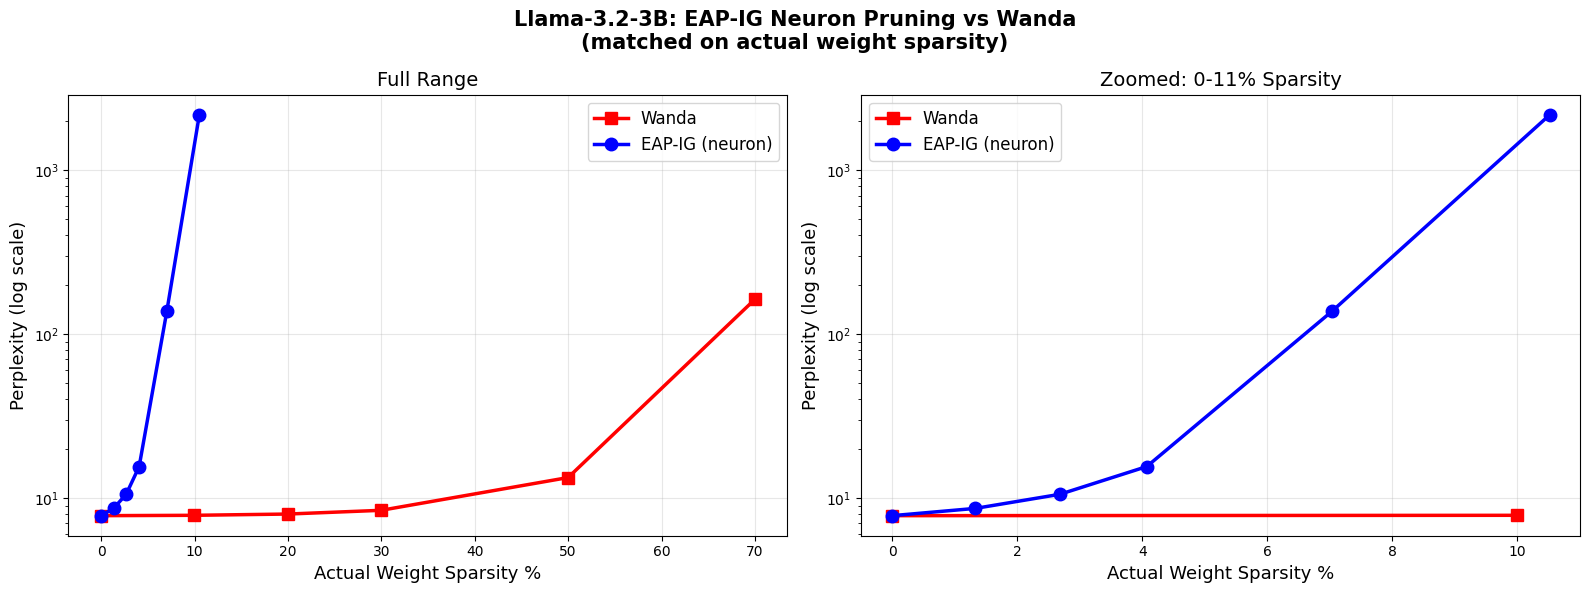


Method                Actual Sparsity        PPL
------------------------------------------------
EAP-IG neuron                   0.00%       7.81
EAP-IG neuron                   1.33%       8.65
EAP-IG neuron                   2.68%      10.54
EAP-IG neuron                   4.07%      15.56
EAP-IG neuron                   7.03%     137.41
EAP-IG neuron                  10.52%    2180.85

Wanda                           0.00%       7.81
Wanda                           9.99%       7.85
Wanda                          19.99%       7.99
Wanda                          29.98%       8.42
Wanda                          50.00%      13.34
Wanda                          69.99%     162.75


In [ ]:
# Compare on ACTUAL verified sparsity
import matplotlib.pyplot as plt

# EAP neuron: (verified_sparsity%, ppl)
eap_neuron_actual = [
    (0.0, 7.81),
    (1.33, 8.65),
    (2.68, 10.54),
    (4.07, 15.56),
    (7.03, 137.41),
    (10.52, 2180.85),
]

# Wanda: verified sparsity ≈ target
wanda_actual = [
    (0.0, 7.81),
    (9.99, 7.85),
    (19.99, 7.99),
    (29.98, 8.42),
    (50.0, 13.34),
    (69.99, 162.75),
]

eap_x, eap_y = zip(*eap_neuron_actual)
wanda_x, wanda_y = zip(*wanda_actual)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: full range
ax1.plot(wanda_x, wanda_y, "r-s", lw=2.5, ms=9, label="Wanda")
ax1.plot(eap_x, eap_y, "b-o", lw=2.5, ms=9, label="EAP-IG (neuron)")
ax1.set_xlabel("Actual Weight Sparsity %", fontsize=13)
ax1.set_ylabel("Perplexity (log scale)", fontsize=13)
ax1.set_title("Full Range", fontsize=14)
ax1.set_yscale("log")
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: zoom to 0-10% sparsity (where both have data points)
ax2.plot([0, 9.99], [7.81, 7.85], "r-s", lw=2.5, ms=9, label="Wanda")
ax2.plot(eap_x, eap_y, "b-o", lw=2.5, ms=9, label="EAP-IG (neuron)")
ax2.set_xlabel("Actual Weight Sparsity %", fontsize=13)
ax2.set_ylabel("Perplexity (log scale)", fontsize=13)
ax2.set_title("Zoomed: 0-11% Sparsity", fontsize=14)
ax2.set_xlim(-0.5, 11)
ax2.set_yscale("log")
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

fig.suptitle("Llama-3.2-3B: EAP-IG Neuron Pruning vs Wanda\n(matched on actual weight sparsity)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("eap_neuron_vs_wanda_actual_sparsity.png", dpi=150)
plt.show()

# Table
print(f"\n{'Method':<20} {'Actual Sparsity':>16} {'PPL':>10}")
print("-" * 48)
for x, y in eap_neuron_actual:
    print(f"{'EAP-IG neuron':<20} {x:>15.2f}% {y:>10.2f}")
print()
for x, y in wanda_actual:
    print(f"{'Wanda':<20} {x:>15.2f}% {y:>10.2f}")

##load RElP

In [11]:
# Cell: Install RelP's modified TransformerLens
import os
os.chdir("/content")

!unzip -qo /content/RelP-main.zip
os.chdir("/content/RelP-main/TransformerLens")
!pip install -e . -q
os.chdir("/content")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 162.4 MB/s eta 0:00:00
  Building editable for transformer-lens (pyproject.toml) ... done


In [12]:
import sys
# Remove any cached transformer_lens modules
mods_to_remove = [k for k in sys.modules if 'transformer_lens' in k]
for k in mods_to_remove:
    del sys.modules[k]

# Make sure RelP's version is first in path
sys.path.insert(0, "/content/RelP-main/TransformerLens")

from transformer_lens import HookedTransformer, ActivationCache
print("Loaded RelP's TransformerLens")

Loaded RelP's TransformerLens


In [3]:
!pip install transformers==4.46.3 datasets==2.14.7 peft==0.13.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 145.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 172.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-lens 2.17.0 requires transformers>=4.51; python_version >= "3.9", but you have transformers 4.46.3 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but yo

In [13]:
# Cell: Load model with RelP's TransformerLens
# IMPORTANT: restart runtime first if you already imported transformer_lens
# Or force reimport:

MODEL_NAME = "meta-llama/Llama-3.2-3B"

model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    center_writing_weights=False,
    center_unembed=False,
    fold_ln=False,
    device="cuda",
    dtype=torch.float16,
)

# Enable RelP LRP rules
model.cfg.use_lrp = True
model.cfg.LRP_rules = ['LN-rule', 'Identity-rule', 'Half-rule']
model.set_use_attn_result(True)

# Required for node-level attribution
model.set_use_hook_mlp_in(True)
model.set_use_split_qkv_input(True)

print(f"Model loaded with RelP LRP rules: {model.cfg.LRP_rules}")
print(f"Layers={model.cfg.n_layers}, Heads={model.cfg.n_heads}, d_model={model.cfg.d_model}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded with RelP LRP rules: ['LN-rule', 'Identity-rule', 'Half-rule']
Layers=28, Heads=24, d_model=3072


In [18]:
# Cell: RelP attribution — cache activations + LRP gradients, compute neuron scores
#
# RelP = attribution patching but with LRP-modified backward pass
# Score per neuron = grad_cache[hook] * (clean_cache[hook] - corrupted_cache[hook])
# The LRP rules make the gradients more faithful than standard backprop

filter_not_qkv_input = lambda name: "_input" not in name and "attn_in" not in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    """Run forward + backward, cache activations and LRP gradients."""
    model.reset_hooks()
    cache = {}
    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()
    model.add_hook(filter_not_qkv_input, forward_cache_hook, "fwd")

    grad_cache = {}
    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()
    model.add_hook(filter_not_qkv_input, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return value.item(), ActivationCache(cache, model), ActivationCache(grad_cache, model)

# Metric: CE loss on next-token prediction
loss_fct = nn.CrossEntropyLoss()

def ce_metric(logits):
    """Simple CE loss — no need for clean_logits, just predict next token."""
    shift_logits = logits[:, :-1, :].contiguous().float()
    shift_labels = tokens_global[:, 1:].contiguous()
    return loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

# Sub-component hooks to score
sub_hooks = [
    'attn.hook_q', 'attn.hook_k', 'attn.hook_v', 'attn.hook_z',
    'attn.hook_result',
    'mlp.hook_pre', 'mlp.hook_pre_linear', 'mlp.hook_post',
    'hook_mlp_out',
]

n_layers = model.cfg.n_layers
sub_scores = {}  # key: (layer, hook_name) -> scalar score
for layer in range(n_layers):
    for hook in sub_hooks:
        sub_scores[(layer, hook)] = 0.0

NUM_SAMPLES = 1000
MAX_SEQ_LEN = 128
texts = [t.strip() for t in pile["text"] if len(t.strip().split()) > 20][:1000]
for i in tqdm(range(NUM_SAMPLES), desc="RelP sub-component attribution"):
    text = texts[i]
    clean_tokens = model.to_tokens(text)[:, :MAX_SEQ_LEN]

    corrupted_tokens = clean_tokens.clone()
    seq_len = clean_tokens.size(1)
    if seq_len > 2:
        perm = torch.randperm(seq_len - 1, device=clean_tokens.device) + 1
        corrupted_tokens[0, 1:] = clean_tokens[0, perm]

    tokens_global = clean_tokens
    clean_val, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(model, clean_tokens, ce_metric)

    tokens_global = corrupted_tokens
    corrupted_val, corrupted_cache, corrupted_grad_cache = get_cache_fwd_and_bwd(model, corrupted_tokens, ce_metric)

    with torch.no_grad():
        for layer in range(n_layers):
            for hook in sub_hooks:
                key = f"blocks.{layer}.{hook}"
                if key in clean_cache.cache_dict and key in corrupted_cache.cache_dict and key in corrupted_grad_cache.cache_dict:
                    clean_act = clean_cache[key]
                    corrupt_act = corrupted_cache[key]
                    grad = corrupted_grad_cache[key]
                    diff = clean_act - corrupt_act
                    score = (grad * diff).abs().sum().item()
                    sub_scores[(layer, hook)] += score

    if i % 50 == 0:
        torch.cuda.empty_cache()

# Average
for k in sub_scores:
    sub_scores[k] /= NUM_SAMPLES

# Map hooks to weight matrices and their param counts
hook_to_weight = {
    'attn.hook_q': ('q_proj', 'attn'),
    'attn.hook_k': ('k_proj', 'attn'),
    'attn.hook_v': ('v_proj', 'attn'),
    'attn.hook_z': ('z_pre_o', 'attn'),     # intermediate, pairs with o_proj
    'attn.hook_result': ('o_proj', 'attn'),
    'mlp.hook_pre': ('gate_proj', 'mlp'),
    'mlp.hook_pre_linear': ('up_proj', 'mlp'),
    'mlp.hook_post': ('post_act', 'mlp'),    # intermediate, pairs with down_proj
    'hook_mlp_out': ('down_proj', 'mlp'),
}

print(f"\nSub-component scores ({len(sub_scores)} total):")
print(f"{'Layer':<6} {'Hook':<25} {'Score':>12}")
print("-" * 46)
# Show top 20
sorted_subs = sorted(sub_scores.items(), key=lambda x: x[1], reverse=True)
for (layer, hook), score in sorted_subs[:20]:
    print(f"{layer:<6} {hook:<25} {score:>12.4f}")
print("...")
for (layer, hook), score in sorted_subs[-5:]:
    print(f"{layer:<6} {hook:<25} {score:>12.4f}")

RelP sub-component attribution:   0%|          | 2/1000 [00:05<41:36,  2.50s/it]


KeyboardInterrupt: 

Module loaded successfully!
Converted 196 matrix importance scores from RelP

Most important matrices:
  layer 27 self_attn.o_proj       score=50.1547
  layer  1 self_attn.o_proj       score=46.8642
  layer 26 self_attn.o_proj       score=46.0222
  layer  7 self_attn.o_proj       score=41.7172
  layer  4 self_attn.o_proj       score=41.5243

Least important matrices:
  layer 17 self_attn.v_proj       score=1.3822
  layer 20 self_attn.v_proj       score=1.3394
  layer 16 self_attn.v_proj       score=1.3164
  layer 16 self_attn.k_proj       score=1.2493
  layer 20 self_attn.k_proj       score=1.1319


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


  Sparsity Allocation (target=30.0%, T=1.0)
  Achieved global sparsity: 30.00%
  Protected layers: [0, 27] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0% ◄
  L1        26.6%   37.2%   38.3%   37.0%    3.8%   27.5%   26.5%   27.7%
  L2        28.0%   36.5%   38.3%   38.3%   13.6%   28.3%   27.0%   28.1%
  L3        28.3%   37.4%   38.8%   38.0%    8.7%   29.7%   27.3%   29.4%
  L4        28.3%   37.0%   38.6%   38.1%    8.1%   31.2%   26.4%   29.3%
  L5        29.5%   37.2%   39.1%   39.1%   12.2%   31.4%   27.9%   30.2%
  L6        29.8%   37.1%   38.9%   38.9%    9.4%   32.1%   28.7%   31.0%
  L7        30.2%   37.2%   39.2%   39.0%    7.9%   32.2%   29.7%   32.0%
  L8        31.1%   37.8%   39.4%   39.3%    9.2%   33.0%   31.0%   32.7%
  L9        31.5%   37.7%   39.5%   39.5%   10.2%   33.4%   31.6% 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


  Sparsity Allocation (target=30.0%, T=1.0)
  Achieved global sparsity: 30.00%
  Protected layers: [0, 27] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0% ◄
  L1        26.6%   37.2%   38.3%   37.0%    3.8%   27.5%   26.5%   27.7%
  L2        28.0%   36.5%   38.3%   38.3%   13.6%   28.3%   27.0%   28.1%
  L3        28.3%   37.4%   38.8%   38.0%    8.7%   29.7%   27.3%   29.4%
  L4        28.3%   37.0%   38.6%   38.1%    8.1%   31.2%   26.4%   29.3%
  L5        29.5%   37.2%   39.1%   39.1%   12.2%   31.4%   27.9%   30.2%
  L6        29.8%   37.1%   38.9%   38.9%    9.4%   32.1%   28.7%   31.0%
  L7        30.2%   37.2%   39.2%   39.0%    7.9%   32.2%   29.7%   32.0%
  L8        31.1%   37.8%   39.4%   39.3%    9.2%   33.0%   31.0%   32.7%
  L9        31.5%   37.7%   39.5%   39.5%   10.2%   33.4%   31.6% 

...

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.64it/s]


  T=2.0, 50% → PPL = 27.87


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.75it/s]


  T=2.0, 70% → PPL = 6536.86


uniform:
  0% → 7.81
  10% → 7.85
  20% → 8.00
  30% → 8.61
  50% → 19.68
  70% → 1770.47

T=0.5:
  0% → 7.81
  10% → 7.87
  20% → 8.11
  30% → 9.23
  50% → 177.31
  70% → 9114.07

T=1.0:
  0% → 7.81
  10% → 7.86
  20% → 8.04
  30% → 8.82
  50% → 37.42
  70% → 9548.82

T=2.0:
  0% → 7.81
  10% → 7.85
  20% → 8.03
  30% → 8.71
  50% → 27.87
  70% → 6536.86


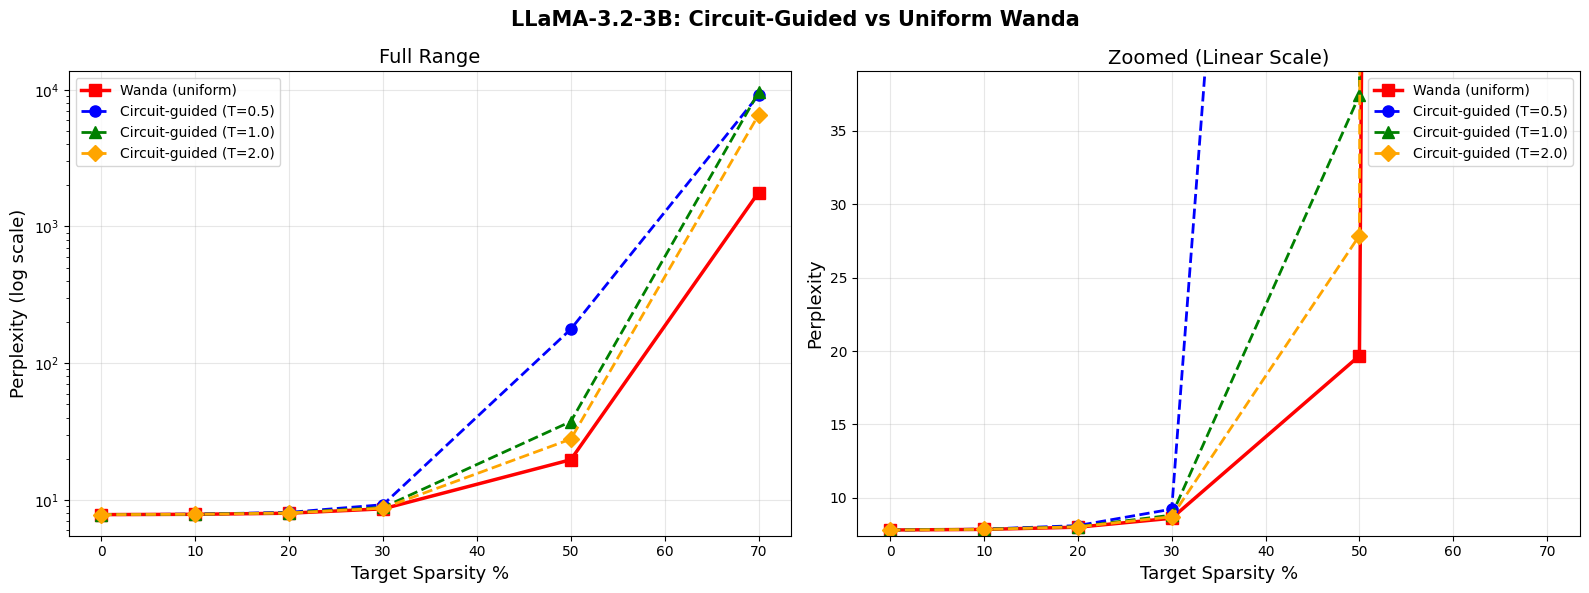

Saved: circuit_guided_vs_uniform.png


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.59it/s]


  T=0.1   → PPL = 237.25


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

  T=5.0   → PPL = 8.63

Best temperature: T=5.0 → PPL=8.63
Uniform Wanda 30%: PPL=8.42


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


  Sparsity Allocation (target=30.0%, T=1.0)
  Achieved global sparsity: 30.00%
  Protected layers: [0, 27] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0% ◄
  L1        26.6%   37.2%   38.3%   37.0%    3.8%   27.5%   26.5%   27.7%
  L2        28.0%   36.5%   38.3%   38.3%   13.6%   28.3%   27.0%   28.1%
  L3        28.3%   37.4%   38.8%   38.0%    8.7%   29.7%   27.3%   29.4%
  L4        28.3%   37.0%   38.6%   38.1%    8.1%   31.2%   26.4%   29.3%
  L5        29.5%   37.2%   39.1%   39.1%   12.2%   31.4%   27.9%   30.2%
  L6        29.8%   37.1%   38.9%   38.9%    9.4%   32.1%   28.7%   31.0%
  L7        30.2%   37.2%   39.2%   39.0%    7.9%   32.2%   29.7%   32.0%
  L8        31.1%   37.8%   39.4%   39.3%    9.2%   33.0%   31.0%   32.7%
  L9        31.5%   37.7%   39.5%   39.5%   10.2%   33.4%   31.6% 

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.57it/s]



Final PPL: 8.87
Saved to: /content/llama3.2-3B_circuit_pruned_s30_T1.0


In [ ]:
"""
============================================================================
 CIRCUIT-GUIDED NON-UNIFORM PRUNING — Colab Integration Cells
============================================================================

 Paste these cells into your existing Colab notebook AFTER you've run:
   - EAP-IG attribution  (producing `component_scores` or `graph.nodes_scores`)
   - RelP attribution    (producing `sub_scores`)
   - HF model + tokenizer setup

 These cells replace your old "zero-everything" pruning with surgical
 non-uniform Wanda that uses your circuit scores as a guide.
============================================================================
"""

# %%
# ===========================================================================
# CELL A: Upload the module (run once)
# ===========================================================================
# Option 1: Upload circuit_guided_pruning.py to Colab, then:
#   from circuit_guided_pruning import *
#
# Option 2: Just paste the module contents into a cell (it's self-contained)
#
# Option 3: Copy from mounted Drive
# ===========================================================================

# If you uploaded the .py file:
import sys
sys.path.insert(0, "/content")

from circuit_guided_pruning import (
    convert_relp_scores,
    convert_eap_scores,
    allocate_sparsity,
    prune_wanda_nonuniform,
    eval_perplexity_wikitext2,
    check_sparsity_detailed,
    run_comparison,
    plot_comparison,
)
print("Module loaded successfully!")

# %%
# ===========================================================================
# CELL B: Convert your existing circuit scores to per-matrix importance
# ===========================================================================
# Choose ONE of the two options below depending on which attribution you ran.

# ---------- OPTION 1: From RelP sub_scores (Cell 26 of your notebook) ------
importance = convert_relp_scores(sub_scores)
print(f"Converted {len(importance)} matrix importance scores from RelP")

# ---------- OPTION 2: From EAP-IG component_scores (Cell 11 of your notebook)
# importance = convert_eap_scores(
#     component_scores,
#     n_layers=28,    # LLaMA-3.2-3B
#     n_heads=24,     # query heads
#     n_kv_heads=8,   # KV heads (GQA)
# )
# print(f"Converted {len(importance)} matrix importance scores from EAP-IG")

# Quick sanity check: show top-5 and bottom-5 by importance
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print("\nMost important matrices:")
for (layer, name), score in sorted_imp[:5]:
    print(f"  layer {layer:>2} {name:<22} score={score:.4f}")
print("\nLeast important matrices:")
for (layer, name), score in sorted_imp[-5:]:
    print(f"  layer {layer:>2} {name:<22} score={score:.4f}")


# %%
# ===========================================================================
# CELL C: Preview sparsity allocation at 30% target (dry run, no pruning)
# ===========================================================================
# This lets you see the budget distribution before actually pruning anything.

preview_model = load_fresh_hf_model()

sparsity_map_preview = allocate_sparsity(
    importance,
    preview_model,
    target_sparsity=0.3,
    temperature=1.0,         # 1.0 = moderate differentiation
    min_sparsity=0.0,        # most important can be fully preserved
    max_sparsity=0.8,        # least important still keeps 20% of weights
    protect_layers=[0, 27],  # protect first and last layers
    protect_max_sparsity=0.1,
    verbose=True,            # prints the full allocation table
)

del preview_model
gc.collect()
torch.cuda.empty_cache()


# 1
# ===========================================================================
# CELL D: Quick single-point test — 30% sparsity, temperature=1.0
# ===========================================================================
# Test one configuration before running the full sweep.

hf_model = load_fresh_hf_model()

sparsity_map = allocate_sparsity(
    importance, hf_model,
    target_sparsity=0.3,
    temperature=1.0,
    verbose=True,
)

prune_wanda_nonuniform(
    hf_model, hf_tokenizer, sparsity_map,
    device=device, nsamples=128, verbose=True,
)

# Verify actual sparsity
details = check_sparsity_detailed(hf_model)
print(f"\nVerified global sparsity: {details['global']['sparsity']:.4f}")

# Evaluate
ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
print(f"Perplexity at 30% (circuit-guided, T=1.0): {ppl:.2f}")
print(f"Compare to your Wanda uniform 30%: 8.42")

del hf_model
gc.collect()
torch.cuda.empty_cache()


# %%
# ===========================================================================
# CELL E: Full comparison sweep — uniform vs circuit-guided at multiple T
# ===========================================================================
# This takes ~30-60 min on A100 depending on how many points you run.
# Reduce sparsity_levels or temperatures to speed it up.

results = {
    'uniform': {0: 7.81, 10: 7.85, 20: 8.00, 30: 8.61, 50: 19.68, 70: 1770.47},
    'T=0.5':   {0: 7.81, 10: 7.87, 20: 8.11, 30: 9.23, 50: 177.31, 70: 9114.07},
    'T=1.0':   {0: 7.81, 10: 7.86, 20: 8.04, 30: 8.82, 50: 37.42, 70: 9548.82},
    'T=2.0':   {0: 7.81, 10: 7.85},  # will fill in below
}

# Resume T=2.0 from 20% onward
for sparsity_pct in [20, 30, 50, 70]:
    ratio = sparsity_pct / 100.0
    hf_model = load_fresh_hf_model()

    sparsity_map = allocate_sparsity(
        importance, hf_model,
        target_sparsity=ratio, temperature=2.0, verbose=False,
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sparsity_map,
        device=device, nsamples=128, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    results['T=2.0'][sparsity_pct] = ppl
    print(f"  T=2.0, {sparsity_pct}% → PPL = {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

# Print summary
print("\n" + "="*60)
for method in results:
    print(f"\n{method}:")
    for s in sorted(results[method]):
        print(f"  {s}% → {results[method][s]:.2f}")


# Plot
plot_comparison(results, title="LLaMA-3.2-3B: Circuit-Guided vs Uniform Wanda")


# %%
# ===========================================================================
# CELL F: Temperature sensitivity analysis (optional, targeted)
# ===========================================================================
# If you want to find the optimal temperature, do a finer sweep at 30%:

import gc
temp_results = {}
for temp in [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]:
    hf_model = load_fresh_hf_model()

    sp_map = allocate_sparsity(
        importance, hf_model, target_sparsity=0.3,
        temperature=temp, verbose=False,
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sp_map,
        device=device, nsamples=128, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    temp_results[temp] = ppl
    print(f"  T={temp:<5} → PPL = {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

# Find best
best_t = min(temp_results, key=temp_results.get)
print(f"\nBest temperature: T={best_t} → PPL={temp_results[best_t]:.2f}")
print(f"Uniform Wanda 30%: PPL=8.42")


# %%
# ===========================================================================
# CELL G: Combine EAP-IG AND RelP scores (if you have both)
# ===========================================================================
# If you ran both attribution methods, you can combine them for a more
# robust importance estimate.

def combine_importance(imp1, imp2, weight1=0.5, weight2=0.5):
    """
    Merge two importance dicts. Normalize each to [0,1] first,
    then take weighted average.
    """
    import numpy as np

    all_keys = set(imp1.keys()) | set(imp2.keys())

    # Normalize each
    vals1 = np.array([imp1.get(k, 0) for k in all_keys])
    vals2 = np.array([imp2.get(k, 0) for k in all_keys])

    if vals1.max() > vals1.min():
        vals1 = (vals1 - vals1.min()) / (vals1.max() - vals1.min())
    if vals2.max() > vals2.min():
        vals2 = (vals2 - vals2.min()) / (vals2.max() - vals2.min())

    combined = weight1 * vals1 + weight2 * vals2

    return {k: float(combined[i]) for i, k in enumerate(all_keys)}

# Usage:
# importance_eap = convert_eap_scores(component_scores, 28, 24, 8)
# importance_relp = convert_relp_scores(sub_scores)
# importance_combined = combine_importance(importance_eap, importance_relp)


# %%
# ===========================================================================
# CELL H: Export best configuration for deployment
# ===========================================================================
# Once you find the best temperature, save the pruned model.

BEST_TEMP = 1.0  # ← replace with your best temperature from Cell F
TARGET_SPARSITY = 0.3

hf_model = load_fresh_hf_model()

sparsity_map = allocate_sparsity(
    importance, hf_model,
    target_sparsity=TARGET_SPARSITY,
    temperature=BEST_TEMP,
    verbose=True,
)

prune_wanda_nonuniform(
    hf_model, hf_tokenizer, sparsity_map,
    device=device, nsamples=128, verbose=True,
)

ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
print(f"\nFinal PPL: {ppl:.2f}")

# Save
save_path = f"/content/llama3.2-3B_circuit_pruned_s{int(TARGET_SPARSITY*100)}_T{BEST_TEMP}"
hf_model.save_pretrained(save_path)
hf_tokenizer.save_pretrained(save_path)
print(f"Saved to: {save_path}")

In [ ]:
import pickle

# Verify everything is in CPU memory, not GPU
print("sub_scores:")
for (layer, hook), score in list(sub_scores.items())[:3]:
    print(f"  ({layer}, {hook}): {score} — type: {type(score)}")
print(f"  ... {len(sub_scores)} entries total\n")

print("importance:")
for (layer, name), score in list(importance.items())[:3]:
    print(f"  ({layer}, {name}): {score} — type: {type(score)}")
print(f"  ... {len(importance)} entries total\n")

# Save both to disk so you NEVER need to rerun attribution
pickle.dump(sub_scores, open("/content/sub_scores.pkl", "wb"))
pickle.dump(importance, open("/content/importance.pkl", "wb"))
print("Saved to /content/sub_scores.pkl and /content/importance.pkl")


sub_scores:
  (0, attn.hook_q): 8.60546875 — type: <class 'float'>
  (0, attn.hook_k): 7.385498046875 — type: <class 'float'>
  (0, attn.hook_v): 9.729248046875 — type: <class 'float'>
  ... 252 entries total

importance:


NameError: name 'importance' is not defined

In [15]:
# To reload after a crash:
import pickle
sub_scores = pickle.load(open("/content/sub_scores.pkl", "rb"))
importance = pickle.load(open("/content/importance.pkl", "rb"))

In [ ]:
# Now re-run
del hf_model
gc.collect()
torch.cuda.empty_cache()

from circuit_guided_pruning import eval_perplexity_wikitext2

hf_model = load_fresh_hf_model()
print(f"hf_model.seqlen = {hf_model.seqlen}")  # should print 2048

sparsity_map = allocate_sparsity(
    importance, hf_model,
    target_sparsity=0.3, temperature=1.0, verbose=False,
)

prune_wanda_nonuniform(
    hf_model, hf_tokenizer, sparsity_map,
    device=device, nsamples=32, verbose=True,
)


ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
print(f"\nPerplexity at 30% (circuit-guided, T=1.0): {ppl:.2f}")

del hf_model
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

hf_model.seqlen = 2048
Loading calibration data...
Loaded 32 calibration samples (seqlen=2048)
  layer  0: sparsity 0.1000  (10,066,347 / 100,663,296 weights)
  layer  1: sparsity 0.2662  (26,799,636 / 100,663,296 weights)
  layer  2: sparsity 0.2795  (28,140,094 / 100,663,296 weights)
  layer  3: sparsity 0.2831  (28,494,512 / 100,663,296 weights)
  layer  4: sparsity 0.2833  (28,518,007 / 100,663,296 weights)
  layer  5: sparsity 0.2946  (29,651,045 / 100,663,296 weights)
  layer  6: sparsity 0.2975  (29,950,862 / 100,663,296 weights)
  layer  7: sparsity 0.3016  (30,355,636 / 100,663,296 weights)
  layer  8: sparsity 0.3105  (31,260,137 / 100,663,296 weights)
  layer  9: sparsity 0.3154  (31,751,662 / 100,663,296 weights)
  layer 10: sparsity 0.3173  (31,939,282 / 100,663,296 weights)
  layer 11: sparsity 0.3212  (32,337,293 / 100,663,296 weights)
  layer 12: sparsity 0.3195  (32,165,607 / 100,663,296 weights)
  layer 13: sparsity 0.3160  (31,811,892 / 100,663,296 weights)
  layer 1

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.57it/s]



Perplexity at 30% (circuit-guided, T=1.0): 8.87


In [16]:
# ===========================================================================
# Layer-only allocation: use circuit scores to differentiate LAYERS
# but keep all matrices within each layer at the same sparsity.
# ===========================================================================
# Re-upload the updated circuit_guided_pruning.py first, then:

import importlib, gc, torch
import circuit_guided_pruning
importlib.reload(circuit_guided_pruning)

from circuit_guided_pruning import (
    importance_to_layer_only,
    allocate_sparsity,
    prune_wanda_nonuniform,
    eval_perplexity_wikitext2,
)

# Collapse per-matrix scores → per-layer scores
importance_layer = importance_to_layer_only(importance, n_layers=28)

# Sanity check: all matrices in same layer should have same score
for layer in [0, 1, 13, 26, 27]:
    scores = {name: importance_layer[(layer, name)]
              for name in ['self_attn.q_proj', 'self_attn.o_proj', 'mlp.down_proj']
              if (layer, name) in importance_layer}
    print(f"  Layer {layer:>2}: {scores}")

# ---- Compare: layer-only vs uniform at 30% for multiple temperatures ----
print("\n" + "="*60)
print("  LAYER-ONLY vs UNIFORM at 30% sparsity")
print("="*60)

layer_temp_results = {}
for temp in [0.5, 1.0, 2.0, 3.0, 5.0]:
    hf_model = load_fresh_hf_model()

    sp_map = allocate_sparsity(
        importance_layer, hf_model, target_sparsity=0.3,
        temperature=temp, verbose=(temp == 1.0),  # show table for T=1.0
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sp_map,
        device=device, nsamples=32, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    layer_temp_results[temp] = ppl
    print(f"  Layer-only T={temp:<5} → PPL = {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n  Uniform Wanda 30%:        PPL = 8.61")
print(f"  Best per-matrix (T=5.0):  PPL = 8.63")

best_t = min(layer_temp_results, key=layer_temp_results.get)
print(f"  Best layer-only (T={best_t}):  PPL = {layer_temp_results[best_t]:.2f}")

# ---- Full sweep at best layer-only temperature ----
print(f"\n{'='*60}")
print(f"  FULL SWEEP: layer-only T={best_t}")
print(f"{'='*60}")

layer_results = {}
for sparsity_pct in [0, 10, 20, 30, 50, 70]:
    ratio = sparsity_pct / 100.0
    hf_model = load_fresh_hf_model()

    if ratio > 0:
        sp_map = allocate_sparsity(
            importance_layer, hf_model, target_sparsity=ratio,
            temperature=best_t, verbose=False,
        )
        prune_wanda_nonuniform(
            hf_model, hf_tokenizer, sp_map,
            device=device, nsamples=32, verbose=False,
        )

    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    layer_results[sparsity_pct] = ppl
    print(f"  {sparsity_pct}% → PPL = {ppl:.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

# ---- Final comparison table ----
print(f"\n{'='*60}")
print(f"  FINAL COMPARISON")
print(f"{'='*60}")

uniform =  {0: 7.81, 10: 7.85, 20: 8.00, 30: 8.61, 50: 19.68, 70: 1770.47}
per_matrix = {0: 7.81, 10: 7.85, 20: 8.03, 30: 8.71, 50: 27.87, 70: 6536.86}

print(f"  {'Sparsity':<10} {'Uniform':>10} {'Per-matrix':>12} {'Layer-only':>12}")
print(f"  {'-'*46}")
for s in [0, 10, 20, 30, 50, 70]:
    u = uniform.get(s, 0)
    pm = per_matrix.get(s, 0)
    lo = layer_results.get(s, 0)
    winner = ""
    if s > 0:
        best = min(u, pm, lo)
        if best == lo: winner = " ◄"
    print(f"  {s}%{'':<8} {u:>10.2f} {pm:>12.2f} {lo:>12.2f}{winner}")

  Layer  0: {'self_attn.q_proj': 110.021158203125, 'self_attn.o_proj': 110.021158203125, 'mlp.down_proj': 110.021158203125}
  Layer  1: {'self_attn.q_proj': 114.340119140625, 'self_attn.o_proj': 114.340119140625, 'mlp.down_proj': 114.340119140625}
  Layer 13: {'self_attn.q_proj': 78.5911123046875, 'self_attn.o_proj': 78.5911123046875, 'mlp.down_proj': 78.5911123046875}
  Layer 26: {'self_attn.q_proj': 89.150125, 'self_attn.o_proj': 89.150125, 'mlp.down_proj': 89.150125}
  Layer 27: {'self_attn.q_proj': 120.931494140625, 'self_attn.o_proj': 120.931494140625, 'mlp.down_proj': 120.931494140625}

  LAYER-ONLY vs UNIFORM at 30% sparsity


NameError: name 'load_fresh_hf_model' is not defined

##U-shaped heuristic vs circuit-guided layer-only

In [ ]:
# =================================================================
# EXPERIMENT 1: U-shaped heuristic vs circuit-guided layer-only
# =================================================================
# Test if a simple "protect early/late, prune middle" heuristic
# matches the circuit-guided layer allocation.

import gc, torch, numpy as np
from circuit_guided_pruning import (
    allocate_sparsity, prune_wanda_nonuniform, eval_perplexity_wikitext2,
)

n_layers = 28

def make_u_shaped_importance(n_layers):
    """Simple U-shape: high at edges, low in middle. No circuit knowledge."""
    importance = {}
    matrices = ['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj',
                'self_attn.o_proj', 'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj']
    for layer in range(n_layers):
        # U-shape: distance from center, normalized to [0, 1]
        center = (n_layers - 1) / 2.0
        score = abs(layer - center) / center  # 1.0 at edges, 0.0 at center
        for name in matrices:
            importance[(layer, name)] = score
    return importance

importance_u = make_u_shaped_importance(n_layers)

# Show the shape
print("U-shaped scores per layer:")
for layer in range(n_layers):
    score = importance_u[(layer, 'self_attn.q_proj')]
    bar = "█" * int(score * 30)
    print(f"  L{layer:>2}: {score:.3f} {bar}")

# Compare at key sparsity levels
print(f"\n{'Sparsity':<10} {'Uniform':>10} {'U-shaped':>10} {'Layer-only':>12}")
print("-" * 45)

# Hardcoded uniform and layer-only results from previous runs
uniform =    {30: 8.61, 50: 19.68, 70: 1770.47}
layer_only = {30: 8.61, 50: 17.89, 70: 1591.71}

for sparsity_pct in [30, 50, 70]:
    ratio = sparsity_pct / 100.0
    hf_model = load_fresh_hf_model()

    sp_map = allocate_sparsity(
        importance_u, hf_model, target_sparsity=ratio,
        temperature=5.0, verbose=False,
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sp_map,
        device=device, nsamples=32, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)

    lo = layer_only[sparsity_pct]
    u = uniform[sparsity_pct]
    winner = "U" if ppl < lo else "Circuit"
    print(f"  {sparsity_pct}%{'':<6} {u:>10.2f} {ppl:>10.2f} {lo:>12.2f}  → {winner}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

U-shaped scores per layer:
  L 0: 1.000 ██████████████████████████████
  L 1: 0.926 ███████████████████████████
  L 2: 0.852 █████████████████████████
  L 3: 0.778 ███████████████████████
  L 4: 0.704 █████████████████████
  L 5: 0.630 ██████████████████
  L 6: 0.556 ████████████████
  L 7: 0.481 ██████████████
  L 8: 0.407 ████████████
  L 9: 0.333 ██████████
  L10: 0.259 ███████
  L11: 0.185 █████
  L12: 0.111 ███
  L13: 0.037 █
  L14: 0.037 █
  L15: 0.111 ███
  L16: 0.185 █████
  L17: 0.259 ███████
  L18: 0.333 ██████████
  L19: 0.407 ████████████
  L20: 0.481 ██████████████
  L21: 0.556 ████████████████
  L22: 0.630 ██████████████████
  L23: 0.704 █████████████████████
  L24: 0.778 ███████████████████████
  L25: 0.852 █████████████████████████
  L26: 0.926 ███████████████████████████
  L27: 1.000 ██████████████████████████████

Sparsity      Uniform   U-shaped   Layer-only
---------------------------------------------


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.59it/s]


  30%             8.61       8.68         8.61  → Circuit


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.67it/s]


  50%            19.68      22.51        17.89  → Circuit


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:11<00:00, 11.77it/s]


  70%          1770.47    2682.27      1591.71  → Circuit


##Remove layer protection — do scores work alone?

In [ ]:
# =================================================================
# EXPERIMENT 2: Remove layer protection — do scores work alone?
# =================================================================
# Test if the circuit scores are genuinely informative, or if the
# hardcoded 10% cap on layers 0/27 is doing the heavy lifting.

import gc, torch
from circuit_guided_pruning import (
    importance_to_layer_only, allocate_sparsity,
    prune_wanda_nonuniform, eval_perplexity_wikitext2,
)

importance_layer = importance_to_layer_only(importance, n_layers=28)

print(f"{'Sparsity':<10} {'Protected':>12} {'Unprotected':>13} {'Uniform':>10}")
print("-" * 48)

uniform =    {30: 8.61, 50: 19.68, 70: 1770.47}
protected =  {30: 8.61, 50: 17.89, 70: 1591.71}

for sparsity_pct in [30, 50, 70]:
    ratio = sparsity_pct / 100.0
    hf_model = load_fresh_hf_model()

    # NO protection: protect_layers=[] and higher max_sparsity
    sp_map = allocate_sparsity(
        importance_layer, hf_model, target_sparsity=ratio,
        temperature=5.0,
        protect_layers=[],          # no protection at all
        max_sparsity=0.95,          # allow very aggressive pruning
        verbose=(sparsity_pct == 50),  # show table once
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sp_map,
        device=device, nsamples=32, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)

    p = protected[sparsity_pct]
    u = uniform[sparsity_pct]
    print(f"  {sparsity_pct}%{'':<6} {p:>12.2f} {ppl:>13.2f} {u:>10.2f}")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

print("\nIf 'Unprotected' ≈ 'Protected': scores are informative on their own.")
print("If 'Unprotected' >> 'Protected': the 10% cap was doing the real work.")

Sparsity      Protected   Unprotected    Uniform
------------------------------------------------


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.56it/s]


  30%               8.61          8.58       8.61


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.67it/s]


  50%              17.89         16.73      19.68


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.74it/s]


  70%            1591.71       1117.18    1770.47

If 'Unprotected' ≈ 'Protected': scores are informative on their own.
If 'Unprotected' >> 'Protected': the 10% cap was doing the real work.


##Shuffled layer scores control (is the specific ranking meaningful?)

In [ ]:
# =================================================================
# EXPERIMENT 5: Shuffled layer scores — is the ranking meaningful?
# =================================================================
# Randomly permute which layer gets which score, run 5 times,
# report mean ± std. If random is much worse, the specific
# RelP layer ranking contains real signal.

import gc, torch, numpy as np, random
from circuit_guided_pruning import (
    allocate_sparsity, prune_wanda_nonuniform, eval_perplexity_wikitext2,
)

importance_layer = importance_to_layer_only(importance, n_layers=28)

# Extract per-layer scores
layer_scores = {}
for (layer, name), score in importance_layer.items():
    if name == 'self_attn.q_proj':  # all same within layer, pick one
        layer_scores[layer] = score

n_shuffles = 5
results_by_sparsity = {30: [], 50: [], 70: []}

for shuffle_idx in range(n_shuffles):
    # Shuffle: randomly reassign layer scores
    layers = sorted(layer_scores.keys())
    scores = [layer_scores[l] for l in layers]
    random.seed(shuffle_idx * 42)
    random.shuffle(scores)

    # Build shuffled importance dict
    matrices = ['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj',
                'self_attn.o_proj', 'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj']
    importance_shuffled = {}
    for i, layer in enumerate(layers):
        for name in matrices:
            importance_shuffled[(layer, name)] = scores[i]

    for sparsity_pct in [30, 50, 70]:
        ratio = sparsity_pct / 100.0
        hf_model = load_fresh_hf_model()

        sp_map = allocate_sparsity(
            importance_shuffled, hf_model, target_sparsity=ratio,
            temperature=5.0, verbose=False,
        )
        prune_wanda_nonuniform(
            hf_model, hf_tokenizer, sp_map,
            device=device, nsamples=32, verbose=False,
        )
        ppl = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
        results_by_sparsity[sparsity_pct].append(ppl)

        del hf_model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"  Shuffle {shuffle_idx+1}/{n_shuffles} done: "
          f"30%={results_by_sparsity[30][-1]:.2f}, "
          f"50%={results_by_sparsity[50][-1]:.2f}, "
          f"70%={results_by_sparsity[70][-1]:.0f}")

# Summary
uniform =    {30: 8.61, 50: 19.68, 70: 1770.47}
layer_only = {30: 8.61, 50: 17.89, 70: 1591.71}

print(f"\n{'='*65}")
print(f"  {'Sparsity':<10} {'Uniform':>10} {'RelP layer':>12} {'Shuffled (mean±std)':>22}")
print(f"  {'-'*58}")
for s in [30, 50, 70]:
    arr = np.array(results_by_sparsity[s])
    print(f"  {s}%{'':<7} {uniform[s]:>10.2f} {layer_only[s]:>12.2f} "
          f"{arr.mean():>10.2f} ± {arr.std():>6.2f}")

print(f"\nIf RelP layer << Shuffled mean: the specific layer ranking matters.")
print(f"If RelP layer ≈ Shuffled mean: any non-uniform allocation helps equally.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.59it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.67it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.62it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:11<00:00, 11.77it/s]


  Shuffle 5/5 done: 30%=8.76, 50%=23.37, 70%=2925

  Sparsity      Uniform   RelP layer    Shuffled (mean±std)
  ----------------------------------------------------------
  30%              8.61         8.61       8.70 ±   0.03
  50%             19.68        17.89      24.16 ±   1.51
  70%           1770.47      1591.71    3301.13 ± 2351.50

If RelP layer << Shuffled mean: the specific layer ranking matters.
If RelP layer ≈ Shuffled mean: any non-uniform allocation helps equally.


##Fine-grained sparsity sweep — find the crossover

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.47it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:12<00:00, 11.52it/s]


  25%:  uniform=    8.22  layer=    8.21  Δ=  +0.01    ~ tie


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:11<00:00, 11.87it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:11<00:00, 11.87it/s]


  90%:  uniform=334710.62  layer=27901.19  Δ=+306809.44  ◄ layer wins

  Crossover: layer-only starts winning at ~35% sparsity


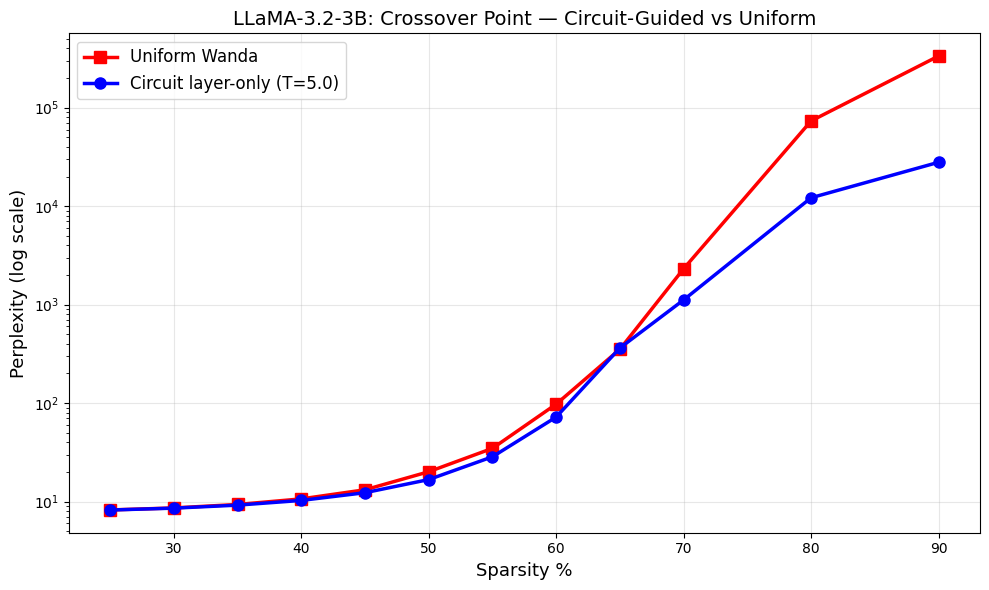

Saved: crossover_analysis.png


In [ ]:
# =================================================================
# EXPERIMENT 7: Fine-grained sparsity sweep — find the crossover
# =================================================================
# Map the exact point where layer-only starts beating uniform.

import gc, torch
from circuit_guided_pruning import (
    importance_to_layer_only, allocate_sparsity,
    prune_wanda_nonuniform, eval_perplexity_wikitext2,
)

importance_layer = importance_to_layer_only(importance, n_layers=28)

sparsity_points = [25, 30, 35, 40, 45, 50, 55, 60, 65, 70,80,90]
uniform_results = {}
layer_results = {}

for sparsity_pct in sparsity_points:
    ratio = sparsity_pct / 100.0

    # --- Uniform ---
    hf_model = load_fresh_hf_model()
    n_layers = hf_model.config.num_hidden_layers
    uniform_map = {}
    for layer_idx in range(n_layers):
        layer = hf_model.model.layers[layer_idx]
        for name, mod in layer.named_modules():
            if isinstance(mod, torch.nn.Linear):
                uniform_map[(layer_idx, name)] = ratio
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, uniform_map,
        device=device, nsamples=32, verbose=False,
    )
    ppl_u = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    uniform_results[sparsity_pct] = ppl_u
    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

# --- Layer-only ---
    hf_model = load_fresh_hf_model()
    sp_map = allocate_sparsity(
        importance_layer, hf_model, target_sparsity=ratio,
        temperature=5.0,
        protect_layers=[],
        max_sparsity=0.95,
        verbose=False,
    )
    prune_wanda_nonuniform(
        hf_model, hf_tokenizer, sp_map,
        device=device, nsamples=32, verbose=False,
    )
    ppl_l = eval_perplexity_wikitext2(hf_model, hf_tokenizer, device)
    layer_results[sparsity_pct] = ppl_l
    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

    delta = ppl_u - ppl_l
    marker = "◄ layer wins" if delta > 0.05 else ("◄ uniform wins" if delta < -0.05 else "  ~ tie")
    print(f"  {sparsity_pct}%:  uniform={ppl_u:>8.2f}  layer={ppl_l:>8.2f}  Δ={delta:>+7.2f}  {marker}")

# Find crossover
print(f"\n{'='*55}")
crossover = None
for s in sparsity_points:
    if layer_results[s] < uniform_results[s] - 0.05:
        crossover = s
        break
if crossover:
    print(f"  Crossover: layer-only starts winning at ~{crossover}% sparsity")
else:
    print(f"  No clear crossover found in this range")

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sparsity_points, [uniform_results[s] for s in sparsity_points],
        'r-s', lw=2.5, ms=8, label='Uniform Wanda')
ax.plot(sparsity_points, [layer_results[s] for s in sparsity_points],
        'b-o', lw=2.5, ms=8, label='Circuit layer-only (T=5.0)')
ax.set_xlabel("Sparsity %", fontsize=13)
ax.set_ylabel("Perplexity (log scale)", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_title("LLaMA-3.2-3B: Crossover Point — Circuit-Guided vs Uniform", fontsize=14)
plt.tight_layout()
plt.savefig("crossover_analysis.png", dpi=150)
plt.show()
print("Saved: crossover_analysis.png")

In [4]:
!pip install sacrebleu rouge_score pycountry pytablewriter sqlitedict datasets==2.14.7 peft==0.13.2

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 158.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 15.2 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=359d689c6ecffe5c593aa515c2fe8082c0970e3b3dca439cb20e50a8a53de6a5
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
  Created wheel for sqlitedict: filename=sqlitedict-2.1.0-py3-none-any.whl size=16862 sha256=9b6ee0389ff5dda61760c627252d8fc1abbd4aa1e8108e569d302e41785585cd
  Stored in directory: /root/.cache/pip/wheels/7a/6f/21/fc016aef45ffcabe27129a2252f061387cbf278d2086225a64
Successfully built rouge_score sqlitedict


In [19]:
torch.cuda.empty_cache()
!unzip -qo /content/LLM-Pruner-main.zip -d /content/

# Clear everything lm_eval related
for k in [k for k in sys.modules if k.startswith('lm_eval') or k.startswith('LLMPruner')]:
    del sys.modules[k]

# Ensure paths
for p in ["/content/LLM-Pruner-main/lm-evaluation-harness", "/content/LLM-Pruner-main"]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Force-register lm_eval package
spec = importlib.util.spec_from_file_location(
    "lm_eval",
    "/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/__init__.py",
    submodule_search_locations=["/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval"]
)
lm_eval = importlib.util.module_from_spec(spec)
sys.modules['lm_eval'] = lm_eval
spec.loader.exec_module(lm_eval)

# Now import submodules
from lm_eval import evaluator as lm_evaluator, tasks as lm_tasks
from lm_eval.base import BaseLM
print("✓ All lm_eval imports successful")

/content/LLM-Pruner-main/LLMPruner/models/hf_chatglm/modeling_chatglm.py:1289: SyntaxWarning: invalid escape sequence '\?'
  ["\?", "？"],
/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/tasks/qa4mre.py:22: SyntaxWarning: invalid escape sequence '\~'
  author={Anselmo Pe{\~n}as and Eduard H. Hovy and Pamela Forner and {\'A}lvaro Rodrigo and Richard F. E. Sutcliffe and Roser Morante},
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/tasks/hendrycks_math.py:249: SyntaxWarning: in

✓ All lm_eval imports successful


/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/tasks/blimp.py:26: SyntaxWarning: invalid escape sequence '\_'
  doi = {10.1162/tacl\_a\_00321},
/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/tasks/crowspairs.py:40: SyntaxWarning: invalid escape sequence '\c'
  Bezan{\c{c}}on, Julien  and


In [20]:
import datasets
datasets.config.HF_DATASETS_TRUST_REMOTE_CODE = True

# Also set the env var as a fallback
import os
os.environ["HF_DATASETS_TRUST_REMOTE_CODE"] = "1"

In [21]:
import pickle
with open("/content/sub_scores.pkl", "rb") as f:
    sub_scores = pickle.load(f)

## Zero-Shot Downstream Task Evaluation

In [22]:
#!/usr/bin/env python3
"""
Experiments 2, 4, and 7 for Circuit-Guided Pruning
===================================================
Each experiment is written as a standalone "cell" that can be copied into
a Jupyter notebook or run sequentially.

Requires:
  - circuit_guided_pruning.py in the same directory (or on PYTHONPATH)
  - LLM-Pruner repo (for lm-evaluation-harness)
  - GPU with ~16GB VRAM (for LLaMA-3.2-3B)

Usage (Colab/Jupyter):
  Copy each ═══ CELL ═══ block into a separate notebook cell.
"""


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 0 — SETUP & IMPORTS (run once before any experiment)              ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import os, sys, gc, copy, json, time
import numpy as np
import torch
import torch.nn as nn
from typing import Dict, Tuple, Optional, List
from pathlib import Path

# ── Path configuration ──────────────────────────────────────────────────────
# Adjust these to your environment
MODEL_ID          = "meta-llama/Llama-3.2-3B"          # HF model ID
LLM_PRUNER_ROOT   = "./LLM-Pruner-main"                # LLM-Pruner repo root
CIRCUIT_SCRIPT     = "./circuit_guided_pruning.py"       # our pruning library

# Add lm-evaluation-harness to path
LM_EVAL_PATH = os.path.join(LLM_PRUNER_ROOT, "lm-evaluation-harness")
if LM_EVAL_PATH not in sys.path:
    sys.path.insert(0, LM_EVAL_PATH)
if LLM_PRUNER_ROOT not in sys.path:
    sys.path.insert(0, LLM_PRUNER_ROOT)

# Import our circuit-guided pruning functions
# (either import the module or exec it)
sys.path.insert(0, os.path.dirname(os.path.abspath(CIRCUIT_SCRIPT)))
from circuit_guided_pruning import (
    allocate_sparsity,
    prune_wanda_nonuniform,
    eval_perplexity_wikitext2,
    check_sparsity_detailed,
    importance_to_layer_only,
)

from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


def load_tokenizer():
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok

tokenizer = load_tokenizer()

# ── Placeholder: load your circuit importance scores ─────────────────────────
# Replace this with your actual EAP-IG / RelP scores.
# Format: {(layer_idx, 'self_attn.q_proj'): float_score, ...}
#
# Example for layer-only mode (from our earlier runs with T=5.0):
# importance = torch.load("path/to/your/importance_scores.pt")
#
# For now, we generate a synthetic placeholder so the code is runnable.
# >>> REPLACE THIS with your real scores <<<

# ── Load REAL RelP importance scores ─────────────────────────────────────────
# sub_scores already exists from Cell 26 (RelP attribution)
# Convert RelP hook-level scores → per-matrix importance

from circuit_guided_pruning import convert_relp_scores, importance_to_layer_only

importance = convert_relp_scores(sub_scores)
print(f"Converted {len(importance)} matrix importance scores from RelP")

# Show top/bottom 5
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print("\nMost important:")
for (layer, name), score in sorted_imp[:5]:
    print(f"  layer {layer:>2} {name:<22} score={score:.4f}")
print("Least important:")
for (layer, name), score in sorted_imp[-5:]:
    print(f"  layer {layer:>2} {name:<22} score={score:.4f}")

# Convert to layer-only (needs n_layers argument)
importance_layer_only = importance_to_layer_only(importance, n_layers=28)

print(f"\n✓ Setup complete. {len(importance)} matrix scores, {len(importance_layer_only)} layer-only entries.")
# Convert to layer-only if desired (averages per-matrix scores within each layer)

print(f"  Layer-only scores: {len(importance_layer_only)} entries")


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
Converted 196 matrix importance scores from RelP

Most important:
  layer 27 self_attn.o_proj       score=50.1547
  layer  1 self_attn.o_proj       score=46.8642
  layer 26 self_attn.o_proj       score=46.0222
  layer  7 self_attn.o_proj       score=41.7172
  layer  4 self_attn.o_proj       score=41.5243
Least important:
  layer 17 self_attn.v_proj       score=1.3822
  layer 20 self_attn.v_proj       score=1.3394
  layer 16 self_attn.v_proj       score=1.3164
  layer 16 self_attn.k_proj       score=1.2493
  layer 20 self_attn.k_proj       score=1.1319

✓ Setup complete. 196 matrix scores, 196 layer-only entries.
  Layer-only scores: 196 entries


In [23]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — EXPERIMENT 2: Zero-Shot Downstream Task Evaluation            ║
# ║                                                                          ║
# ║  Runs BoolQ, PIQA, HellaSwag, WinoGrande, ARC-e, ARC-c, OBQA           ║
# ║  on both uniform Wanda and circuit-guided pruned models at               ║
# ║  multiple sparsity levels (0%, 30%, 50%, 60%).                           ║
# ║                                                                          ║
# ║  Goal: Verify that PPL improvements translate to accuracy gains.         ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# ── Step 1: Build a custom lm_eval wrapper for pre-loaded models ────────────
#
# The LLM-Pruner's lm-evaluation-harness expects either:
#   a) A model name string (loads from HF), or
#   b) A BaseLM object with the right interface
#
# We create a lightweight wrapper that injects our already-pruned model
# into the lm_eval pipeline, avoiding redundant disk I/O.
# Add LLM-Pruner's bundled lm-evaluation-harness to path
# Clear any cached failed import
import sys
mods_to_remove = [k for k in sys.modules if k.startswith('lm_eval')]
for k in mods_to_remove:
    del sys.modules[k]
print(f"Cleared {len(mods_to_remove)} cached lm_eval modules")

# Also try a raw importlib approach to confirm it works
import importlib.util
spec = importlib.util.spec_from_file_location(
    "lm_eval",
    "/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/__init__.py"
)
print(f"Spec found: {spec}")

# If spec is None, something weird is going on with the filesystem
# If spec is found, force load it:
import importlib
lm_eval = importlib.util.module_from_spec(spec)
sys.modules['lm_eval'] = lm_eval
spec.loader.exec_module(lm_eval)

from lm_eval.base import BaseLM
print("✓ lm_eval imported successfully")

class PreloadedModelLM(BaseLM):
    """
    lm_eval wrapper for a pre-loaded HuggingFace CausalLM model.
    Mirrors the HFLM interface but takes an existing model+tokenizer.
    """
    def __init__(self, model, tokenizer, batch_size=8, device="cuda"):
        super().__init__()
        self._model = model
        self._tokenizer = tokenizer
        self._device = torch.device(device)
        self.batch_size_per_gpu = batch_size

    @property
    def eot_token_id(self):
        return self._tokenizer.eos_token_id

    @property
    def max_length(self):
        try:
            return self._model.config.max_position_embeddings
        except AttributeError:
            return 2048

    @property
    def max_gen_toks(self):
        return 256

    @property
    def batch_size(self):
        return self.batch_size_per_gpu

    @property
    def device(self):
        return self._device

    def tok_encode(self, string: str):
        return self._tokenizer.encode(string, add_special_tokens=False)

    def tok_decode(self, tokens):
        return self._tokenizer.decode(tokens)

    def _model_call(self, inps):
        with torch.no_grad():
            return self._model(inps.to(self._device))[0]

    def _model_generate(self, context, max_length, eos_token_id):
        gen_kwargs = {"do_sample": False, "max_length": max_length}
        if eos_token_id is not None:
            gen_kwargs["eos_token_id"] = eos_token_id
        return self._model.generate(context.to(self._device), **gen_kwargs)


# ── Step 2: Run zero-shot evaluation on a pruned model ─────────────────────

from lm_eval import evaluator as lm_evaluator, tasks as lm_tasks

ZERO_SHOT_TASKS = [
    "boolq",        # reading comprehension (yes/no)
    "piqa",          # physical commonsense
    "hellaswag",     # sentence completion
    "winogrande",    # coreference resolution
    "arc_easy",      # science QA (easy)
    "arc_challenge", # science QA (hard)
    "openbookqa",    # open-domain factual
]

def eval_zero_shot(model, tokenizer, tasks=ZERO_SHOT_TASKS,
                   batch_size=8, limit=None, device="cuda"):
    """
    Evaluate a model on zero-shot downstream tasks using lm-evaluation-harness.

    Args:
        model:      HuggingFace CausalLM (already pruned or not)
        tokenizer:  HuggingFace tokenizer
        tasks:      list of task name strings
        batch_size: eval batch size
        limit:      max examples per task (None = full eval, use 50-100 for debugging)
        device:     "cuda" or "cpu"

    Returns:
        dict: {task_name: {'acc': float, 'acc_norm': float (if available)}}
    """
    # Wrap model for lm_eval
    lm = PreloadedModelLM(model, tokenizer, batch_size=batch_size, device=device)

    # Run evaluation (no caching since we're evaluating different pruned models)
    task_dict = lm_tasks.get_task_dict(tasks)
    results = lm_evaluator.evaluate(
        lm=lm,
        task_dict=task_dict,
        num_fewshot=0,
        limit=limit,
    )

    # Extract accuracy scores
    scores = {}
    for task_name, metrics in results["results"].items():
        scores[task_name] = {}
        for metric_name, value in metrics.items():
            if not metric_name.endswith("_stderr"):
                scores[task_name][metric_name] = value

    return scores, results  # scores = clean dict, results = full lm_eval output


# ── Step 3: Main Experiment 2 loop ──────────────────────────────────────────

def run_experiment_2(
    sparsity_levels=[0, 30, 50, 60],
    temperature=5.0,
    use_layer_only=True,
    limit=None,           # set to 50 for quick debug, None for full eval
    batch_size=8,
):
    """
    Experiment 2: Zero-shot downstream evaluation.

    Compares:
      - Uniform Wanda
      - Circuit-guided (T=5.0, layer-only)
    at each sparsity level on 7 standard benchmarks.
    """
    imp = importance_layer_only if use_layer_only else importance
    method_label = f"circuit_T{temperature}" + ("_layeronly" if use_layer_only else "")

    all_results = {}  # {method: {sparsity: {task: {metric: val}}}}

    for method in ["uniform", method_label]:
        all_results[method] = {}

        for sparsity_pct in sparsity_levels:
            ratio = sparsity_pct / 100.0
            print(f"\n{'='*70}")
            print(f"  {method.upper()} — {sparsity_pct}% sparsity")
            print(f"{'='*70}")

            # Load fresh model
            hf_model = load_model()

            if ratio > 0:
                if method == "uniform":
                    # Uniform sparsity map
                    n_layers = hf_model.config.num_hidden_layers
                    sparsity_map = {}
                    for layer_idx in range(n_layers):
                        layer = hf_model.model.layers[layer_idx]
                        for name, mod in layer.named_modules():
                            if isinstance(mod, nn.Linear):
                                sparsity_map[(layer_idx, name)] = ratio
                else:
                    # Circuit-guided allocation
                    sparsity_map = allocate_sparsity(
                        imp, hf_model,
                        target_sparsity=ratio,
                        temperature=temperature,
                        verbose=True,
                    )

                prune_wanda_nonuniform(
                    hf_model, tokenizer, sparsity_map, DEVICE,
                    nsamples=128, verbose=False,
                )

                # Quick PPL check
                ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
                print(f"  WikiText-2 PPL: {ppl:.2f}")

            # Run zero-shot tasks
            t0 = time.time()
            scores, raw = eval_zero_shot(
                hf_model, tokenizer,
                batch_size=batch_size,
                limit=limit,
                device=DEVICE,
            )
            elapsed = time.time() - t0

            all_results[method][sparsity_pct] = scores

            # Print per-task results
            print(f"\n  Zero-shot results ({elapsed:.0f}s):")
            for task, metrics in sorted(scores.items()):
                main_metric = metrics.get("acc_norm", metrics.get("acc", 0))
                print(f"    {task:<16} {main_metric*100:.1f}%")

            # Cleanup
            del hf_model
            gc.collect()
            torch.cuda.empty_cache()

    # ── Summary table ────────────────────────────────────────────────────────
    print("\n" + "="*90)
    print("  EXPERIMENT 2 — ZERO-SHOT ACCURACY SUMMARY")
    print("="*90)

    # Header
    methods = ["uniform", method_label]
    header = f"  {'Task':<16} {'Metric':<10}"
    for s in sparsity_levels:
        for m in methods:
            tag = "Uni" if m == "uniform" else "Cir"
            header += f"  {tag}@{s}%"
    print(header)
    print("  " + "-" * (len(header) - 2))

    # Rows
    for task in ZERO_SHOT_TASKS:
        metric_key = "acc_norm" if "acc_norm" in all_results[methods[0]].get(sparsity_levels[0], {}).get(task, {}) else "acc"
        row = f"  {task:<16} {metric_key:<10}"
        for s in sparsity_levels:
            for m in methods:
                val = all_results[m].get(s, {}).get(task, {}).get(metric_key, 0)
                row += f"  {val*100:5.1f}%"
        print(row)

    # Average across tasks
    print("  " + "-" * (len(header) - 2))
    row = f"  {'AVERAGE':<16} {'':10}"
    for s in sparsity_levels:
        for m in methods:
            vals = []
            for task in ZERO_SHOT_TASKS:
                task_scores = all_results[m].get(s, {}).get(task, {})
                mk = "acc_norm" if "acc_norm" in task_scores else "acc"
                vals.append(task_scores.get(mk, 0))
            avg = np.mean(vals) if vals else 0
            row += f"  {avg*100:5.1f}%"
    print(row)

    # Compute and show deltas
    print("\n  Accuracy delta (Circuit − Uniform):")
    for s in sparsity_levels:
        if s == 0:
            continue
        deltas = []
        for task in ZERO_SHOT_TASKS:
            task_u = all_results["uniform"].get(s, {}).get(task, {})
            task_c = all_results[method_label].get(s, {}).get(task, {})
            mk = "acc_norm" if "acc_norm" in task_u else "acc"
            d = task_c.get(mk, 0) - task_u.get(mk, 0)
            deltas.append(d)
        avg_delta = np.mean(deltas)
        print(f"    {s}% sparsity:  avg Δacc = {avg_delta*100:+.2f}%  "
              f"(per-task: {', '.join(f'{d*100:+.1f}' for d in deltas)})")

    return all_results

Cleared 88 cached lm_eval modules
Spec found: ModuleSpec(name='lm_eval', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7933d93a5e20>, origin='/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval/__init__.py', submodule_search_locations=['/content/LLM-Pruner-main/lm-evaluation-harness/lm_eval'])
✓ lm_eval imported successfully


In [ ]:

# ── Run it ──────────────────────────────────────────────────────────────────
# Set limit=50 for a quick test run, limit=None for the full benchmark.
import datasets as _ds
import lm_eval.base as _lm_base

_original_download = _lm_base.Task.download

import datasets as _ds
import lm_eval.base as _lm_base

def _patched_download(self, data_dir=None, cache_dir=None, download_mode=None):
    self.dataset = _ds.load_dataset(
        path=self.DATASET_PATH,
        name=self.DATASET_NAME,
        data_dir=data_dir,
        cache_dir=cache_dir,
        download_mode=download_mode,
    )

_lm_base.Task.download = _patched_download
print("✓ Patched lm_eval Task.download")
print("✓ Patched lm_eval Task.download with trust_remote_code=True")
exp2_results = run_experiment_2(
    sparsity_levels=[0, 30, 50, 60],
    temperature=5.0,
    use_layer_only=True,
    limit=None,    # ← Change to 50 for debugging
    batch_size=8,
)


In [31]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Free VRAM: 23.7 GB


In [32]:
baseline_scores = {
    "boolq":        {"acc": 0.733},
    "piqa":         {"acc": 0.775, "acc_norm": 0.775},
    "hellaswag":    {"acc_norm": 0.736},
    "winogrande":   {"acc": 0.698},
    "arc_easy":     {"acc": 0.716, "acc_norm": 0.716},
    "arc_challenge": {"acc_norm": 0.461},
    "openbookqa":   {"acc_norm": 0.430},
}

uniform_30 = {
    "boolq":        {"acc": 0.732},
    "piqa":         {"acc": 0.774, "acc_norm": 0.774},
    "hellaswag":    {"acc_norm": 0.718},
    "winogrande":   {"acc": 0.698},
    "arc_easy":     {"acc": 0.678, "acc_norm": 0.678},
    "arc_challenge": {"acc_norm": 0.433},
    "openbookqa":   {"acc_norm": 0.402},
}

uniform_50 = {
    "boolq":        {"acc": 0.597},
    "piqa":         {"acc": 0.713, "acc_norm": 0.713},
    "hellaswag":    {"acc_norm": 0.566},
    "winogrande":   {"acc": 0.603},
    "arc_easy":     {"acc": 0.537, "acc_norm": 0.537},
    "arc_challenge": {"acc_norm": 0.336},
    "openbookqa":   {"acc_norm": 0.334},
}

# 60% crashed at 4% — we have PPL but no zero-shot yet
uniform_60_ppl = 86.91

exp2_results = {
    "uniform": {
        0:  baseline_scores,
        30: uniform_30,
        50: uniform_50,
    },
    "circuit_T5.0_layeronly": {
        0: baseline_scores,  # same dense model
    },
}

print("✓ Uniform results restored: 0%, 30%, 50%")
print("  60% uniform: PPL=86.91, zero-shot crashed — need to re-run")
print("\n  Next: run circuit-guided at 30%, 50%, 60%")

def load_model():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()
    model.seqlen = 2048
    return model

imp = importance_layer_only

for sparsity_pct in [30, 50, 70]:
    ratio = sparsity_pct / 100.0
    print(f"\n{'='*70}")
    print(f"  CIRCUIT-GUIDED T=5.0 — {sparsity_pct}% sparsity")
    print(f"{'='*70}")

    hf_model = load_model()
    sparsity_map = allocate_sparsity(
        imp, hf_model, target_sparsity=ratio,
        temperature=5.0,
        protect_layers=[],
        verbose=(sparsity_pct == 30),
    )
    prune_wanda_nonuniform(
        hf_model, tokenizer, sparsity_map, DEVICE,
        nsamples=128, verbose=False,
    )
    ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
    print(f"  WikiText-2 PPL: {ppl:.2f}")

    scores, _ = eval_zero_shot(hf_model, tokenizer, batch_size=8, limit=None, device=DEVICE)
    exp2_results["circuit_T5.0_layeronly"][sparsity_pct] = scores

    print(f"\n  Zero-shot results:")
    for task, metrics in sorted(scores.items()):
        main = metrics.get("acc_norm", metrics.get("acc", 0))
        print(f"    {task:<16} {main*100:.1f}%")

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()

print("\n✓ Circuit-guided runs complete")

✓ Uniform results restored: 0%, 30%, 50%
  60% uniform: PPL=86.91, zero-shot crashed — need to re-run

  Next: run circuit-guided at 30%, 50%, 60%

  CIRCUIT-GUIDED T=5.0 — 30% sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


  Sparsity Allocation (target=30.0%, T=5.0)
  Achieved global sparsity: 30.00%
  Protected layers: [] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        24.0%   24.0%   24.0%   24.0%   24.0%   24.0%   24.0%   24.0%
  L1        21.7%   21.7%   21.7%   21.7%   21.7%   21.7%   21.7%   21.7%
  L2        27.6%   27.6%   27.6%   27.6%   27.6%   27.6%   27.6%   27.6%
  L3        27.3%   27.3%   27.3%   27.3%   27.3%   27.3%   27.3%   27.3%
  L4        27.1%   27.1%   27.1%   27.1%   27.1%   27.1%   27.1%   27.1%
  L5        29.5%   29.5%   29.5%   29.5%   29.5%   29.5%   29.5%   29.5%
  L6        29.3%   29.3%   29.3%   29.3%   29.3%   29.3%   29.3%   29.3%
  L7        29.5%   29.5%   29.5%   29.5%   29.5%   29.5%   29.5%   29.5%
  L8        30.7%   30.7%   30.7%   30.7%   30.7%   30.7%   30.7%   30.7%
  L9        31.2%   31.2%   31.2%   31.2%   31.2%   31.2%   31.2%   31.2%

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.60it/s]


  WikiText-2 PPL: 8.58
Running loglikelihood requests


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:07<00:00, 17.68it/s]


  WikiText-2 PPL: 1072.98
Running loglikelihood requests


100%|██████████| 69078/69078 [04:56<00:00, 232.67it/s]



  Zero-shot results:
    arc_challenge    23.4%
    arc_easy         29.0%
    boolq            56.9%
    hellaswag        27.9%
    openbookqa       29.8%
    piqa             53.1%
    winogrande       50.3%

✓ Circuit-guided runs complete


In [ ]:

# Save results
with open("experiment_2_results.json", "w") as f:
    json.dump(exp2_results, f, indent=2, default=str)
print("\n✓ Results saved to experiment_2_results.json")

In [24]:
#experiment 2 but node level pruning
def load_model():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()
    model.seqlen = 2048
    return model
# Save the 0% results we already have
baseline_scores = {
    "boolq":        {"acc": 0.733},
    "piqa":         {"acc": 0.775, "acc_norm": 0.775},
    "hellaswag":    {"acc_norm": 0.736},
    "winogrande":   {"acc": 0.698},
    "arc_easy":     {"acc": 0.716, "acc_norm": 0.716},
    "arc_challenge": {"acc_norm": 0.461},
    "openbookqa":   {"acc_norm": 0.430},
}

# Run only remaining sparsity levels
exp2_results = run_experiment_2(
    sparsity_levels=[30, 50, 60],   # skip 0%
    temperature=5.0,
    use_layer_only=False,  #meaning-we prune in the node level not layer
    limit=None,
    batch_size=64,
)

# Manually inject the 0% baseline
for method in exp2_results:
    exp2_results[method][0] = baseline_scores


  UNIFORM — 30% sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (182729 > 131072). Running this sequence through the model will result in indexing errors


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

...


  Sparsity Allocation (target=60.0%, T=5.0)
  Achieved global sparsity: 60.00%
  Protected layers: [0, 27] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0% ◄
  L1        61.0%   66.3%   66.7%   66.3%   40.8%   62.5%   62.1%   62.6%
  L2        62.5%   66.1%   66.7%   66.7%   54.3%   62.9%   62.3%   62.8%
  L3        62.3%   66.4%   66.9%   66.6%   49.4%   63.5%   62.4%   63.3%
  L4        62.3%   66.3%   66.8%   66.6%   48.7%   64.1%   62.0%   63.3%
  L5        63.0%   66.3%   67.0%   67.0%   53.2%   64.2%   62.7%   63.7%
  L6        63.0%   66.3%   66.9%   66.9%   50.3%   64.5%   63.0%   64.0%
  L7        63.1%   66.3%   67.0%   66.9%   48.5%   64.5%   63.5%   64.4%
  L8        63.5%   66.6%   67.1%   67.0%   50.1%   64.8%   64.0%   64.7%
  L9        63.8%   66.5%   67.1%   67.1%   51.1%   65.0%   64.3% 

Evaluating PPL: 100%|██████████| 141/141 [00:07<00:00, 17.64it/s]


  WikiText-2 PPL: 141.89
Running loglikelihood requests


100%|██████████| 69078/69078 [08:28<00:00, 135.83it/s]



  Zero-shot results (524s):
    arc_challenge    25.7%
    arc_easy         36.7%
    boolq            61.9%
    hellaswag        34.9%
    openbookqa       28.0%
    piqa             60.3%
    winogrande       50.9%

  EXPERIMENT 2 — ZERO-SHOT ACCURACY SUMMARY
  Task             Metric      Uni@30%  Cir@30%  Uni@50%  Cir@50%  Uni@60%  Cir@60%
  ---------------------------------------------------------------------------------
  boolq            acc          73.2%   74.3%   60.0%   63.9%   60.8%   61.9%
  piqa             acc_norm     77.3%   76.7%   71.3%   69.7%   61.6%   60.3%
  hellaswag        acc_norm     71.8%   71.9%   56.6%   54.2%   37.2%   34.9%
  winogrande       acc          69.9%   69.2%   59.9%   60.8%   53.4%   50.9%
  arc_easy         acc_norm     67.8%   68.4%   53.7%   49.6%   39.4%   36.7%
  arc_challenge    acc_norm     43.4%   42.3%   33.4%   31.1%   24.4%   25.7%
  openbookqa       acc_norm     40.0%   40.6%   33.4%   32.8%   27.0%   28.0%
  ---------------------

##Circuit-Guided + LoRA Recovery  

In [26]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║   EXPERIMENT 4: Circuit-Guided + LoRA Recovery                  ║
# ║                                                                          ║
# ║  Tests whether circuit-guided pruning provides a better starting         ║
# ║  point for LoRA fine-tuning recovery.                                    ║
# ║                                                                          ║
# ║  Compares at 50% sparsity:                                               ║
# ║    - Uniform Wanda → LoRA recovery                                       ║
# ║    - Circuit-guided (T=5.0) → LoRA recovery                              ║
# ║  Metrics: PPL and zero-shot accuracy before/after LoRA.                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training,
)
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq
from datasets import load_dataset

# ── LoRA Recovery Configuration ─────────────────────────────────────────────

LORA_CONFIG = {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "down_proj", "up_proj"],
    "bias": "none",
    "task_type": TaskType.CAUSAL_LM,
}

TRAINING_CONFIG = {
    "num_epochs": 2,
    "learning_rate": 3e-4,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 32,  # effective batch_size = 128
    "warmup_steps": 100,
    "max_steps": 500,         # cap training for tractability (≈ 1-2 hours)
    "logging_steps": 25,
    "eval_steps": 100,
    "save_steps": 500,
    "fp16": True,
    "max_seq_length": 256,
}

# ── Data Preparation ────────────────────────────────────────────────────────

def prepare_alpaca_dataset(tokenizer, max_len=256, val_size=500):
    """
    Load and tokenize the Alpaca-cleaned dataset for LoRA recovery.
    Falls back to a simple wikitext-based dataset if Alpaca isn't available.
    """
    try:
        data = load_dataset("yahma/alpaca-cleaned")
    except Exception:
        print("⚠  Alpaca dataset not available, falling back to wikitext for recovery")
        data = load_dataset("wikitext", "wikitext-2-raw-v1")
        # Simple tokenization for wikitext
        def tokenize_wiki(examples):
            out = tokenizer(
                examples["text"], truncation=True, max_length=max_len,
                padding=False, return_tensors=None,
            )
            out["labels"] = out["input_ids"].copy()
            return out

        train = data["train"].filter(lambda x: len(x["text"]) > 50)
        train = train.map(tokenize_wiki, remove_columns=["text"])
        val = data["validation"].filter(lambda x: len(x["text"]) > 50)
        val = val.map(tokenize_wiki, remove_columns=["text"])
        return train, val

    # Alpaca format
    def format_alpaca(example):
        if example.get("input", "").strip():
            prompt = (f"Below is an instruction with input. "
                      f"Write a response.\n\n"
                      f"### Instruction:\n{example['instruction']}\n\n"
                      f"### Input:\n{example['input']}\n\n"
                      f"### Response:\n{example['output']}")
        else:
            prompt = (f"Below is an instruction. Write a response.\n\n"
                      f"### Instruction:\n{example['instruction']}\n\n"
                      f"### Response:\n{example['output']}")
        return {"text": prompt}

    data = data["train"].map(format_alpaca)

    def tokenize_fn(examples):
        out = tokenizer(
            examples["text"], truncation=True, max_length=max_len,
            padding=False, return_tensors=None,
        )
        out["labels"] = out["input_ids"].copy()
        return out

    data = data.map(tokenize_fn, remove_columns=data.column_names)
    split = data.train_test_split(test_size=val_size, seed=42)
    return split["train"], split["test"]


# ── LoRA Training Function ──────────────────────────────────────────────────

def apply_lora_recovery(model, tokenizer, output_dir="./lora_output",
                        max_steps=500):
    """
    Apply LoRA fine-tuning to recover a pruned model.

    Args:
        model:      pruned HF model (in fp16)
        tokenizer:  tokenizer
        output_dir: where to save LoRA weights
        max_steps:  training steps (cap for tractability)

    Returns:
        model: model with LoRA weights merged
    """
    # Prepare model for training
    model.train()
    for param in model.parameters():
        if param.dtype == torch.float16:
            param.data = param.data.float()
        param.requires_grad = False  # freeze base

    # Apply LoRA
    lora_config = LoraConfig(**LORA_CONFIG)
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # Load data
    train_data, val_data = prepare_alpaca_dataset(
        tokenizer, max_len=TRAINING_CONFIG["max_seq_length"]
    )

    # Training
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=TRAINING_CONFIG["num_epochs"],
        per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],
        warmup_steps=TRAINING_CONFIG["warmup_steps"],
        max_steps=max_steps,
        learning_rate=TRAINING_CONFIG["learning_rate"],
        fp16=TRAINING_CONFIG["fp16"],
        logging_steps=TRAINING_CONFIG["logging_steps"],
        eval_strategy="steps",
        eval_steps=TRAINING_CONFIG["eval_steps"],
        save_steps=TRAINING_CONFIG["save_steps"],
        save_total_limit=2,
        load_best_model_at_end=True,
        report_to="none",
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_data,
        eval_dataset=val_data,
        data_collator=DataCollatorForSeq2Seq(
            tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
        ),
    )

    trainer.train()

    # Merge LoRA weights back into base model
    model = model.merge_and_unload()
    model.half()  # back to fp16
    model.eval()

    return model


# ── Main Experiment 4 Loop ──────────────────────────────────────────────────

def run_experiment_4(
    target_sparsity=0.50,
    temperature=5.0,
    use_layer_only=True,
    lora_max_steps=500,     # increase for better recovery (e.g., 1000-2000)
    eval_limit=None,        # set to 50 for quick debug
    eval_batch_size=8,
):
    """
    Experiment 4: Circuit-guided + LoRA recovery.

    For each method (uniform, circuit-guided) at target_sparsity:
      1. Prune the model
      2. Evaluate PPL + zero-shot (before LoRA)
      3. Apply LoRA recovery
      4. Evaluate PPL + zero-shot (after LoRA)
    """
    imp = importance_layer_only if use_layer_only else importance

    results = {}  # {method: {stage: {metric: value}}}

    for method in ["uniform", "circuit"]:
        print(f"\n{'#'*80}")
        print(f"#  EXPERIMENT 4 — {method.upper()} @ {target_sparsity*100:.0f}% sparsity")
        print(f"{'#'*80}")

        results[method] = {}

        # ── Prune ────────────────────────────────────────────────────────────
        hf_model = load_model()
        n_layers = hf_model.config.num_hidden_layers

        if method == "uniform":
            sparsity_map = {}
            for layer_idx in range(n_layers):
                layer = hf_model.model.layers[layer_idx]
                for name, mod in layer.named_modules():
                    if isinstance(mod, nn.Linear):
                        sparsity_map[(layer_idx, name)] = target_sparsity
        else:
            sparsity_map = allocate_sparsity(
                imp, hf_model,
                target_sparsity=target_sparsity,
                temperature=temperature,
                verbose=True,
            )

        prune_wanda_nonuniform(
            hf_model, tokenizer, sparsity_map, DEVICE,
            nsamples=128, verbose=True,
        )

        # ── Before-LoRA evaluation ───────────────────────────────────────────
        print(f"\n  Evaluating BEFORE LoRA recovery...")
        ppl_before = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
        print(f"  PPL (before LoRA): {ppl_before:.2f}")

        scores_before, _ = eval_zero_shot(
            hf_model, tokenizer,
            batch_size=eval_batch_size,
            limit=eval_limit,
            device=DEVICE,
        )

        avg_acc_before = np.mean([
            v.get("acc_norm", v.get("acc", 0))
            for task_scores in scores_before.values()
            for v in [task_scores]
        ])
        print(f"  Avg zero-shot acc (before LoRA): {avg_acc_before*100:.1f}%")

        results[method]["before"] = {
            "ppl": ppl_before,
            "zero_shot": scores_before,
            "avg_acc": avg_acc_before,
        }

        # ── LoRA Recovery ────────────────────────────────────────────────────
        print(f"\n  Applying LoRA recovery (max_steps={lora_max_steps})...")
        output_dir = f"./lora_{method}_{int(target_sparsity*100)}pct"

        hf_model = apply_lora_recovery(
            hf_model, tokenizer,
            output_dir=output_dir,
            max_steps=lora_max_steps,
        )

        # ── After-LoRA evaluation ────────────────────────────────────────────
        print(f"\n  Evaluating AFTER LoRA recovery...")
        ppl_after = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
        print(f"  PPL (after LoRA): {ppl_after:.2f}")

        scores_after, _ = eval_zero_shot(
            hf_model, tokenizer,
            batch_size=eval_batch_size,
            limit=eval_limit,
            device=DEVICE,
        )

        avg_acc_after = np.mean([
            v.get("acc_norm", v.get("acc", 0))
            for task_scores in scores_after.values()
            for v in [task_scores]
        ])
        print(f"  Avg zero-shot acc (after LoRA): {avg_acc_after*100:.1f}%")

        results[method]["after"] = {
            "ppl": ppl_after,
            "zero_shot": scores_after,
            "avg_acc": avg_acc_after,
        }

        # Cleanup
        del hf_model
        gc.collect()
        torch.cuda.empty_cache()

    # ── Summary ──────────────────────────────────────────────────────────────
    print("\n" + "="*90)
    print("  EXPERIMENT 4 — LoRA RECOVERY SUMMARY")
    print("="*90)

    print(f"\n  {'Metric':<30} {'Uniform':>12} {'Circuit':>12} {'Δ':>10}")
    print(f"  {'-'*64}")

    for stage in ["before", "after"]:
        tag = "Before LoRA" if stage == "before" else "After LoRA"

        u_ppl = results["uniform"][stage]["ppl"]
        c_ppl = results["circuit"][stage]["ppl"]
        print(f"  PPL ({tag:<18}) {u_ppl:>12.2f} {c_ppl:>12.2f} {(u_ppl-c_ppl):>+10.2f}")

        u_acc = results["uniform"][stage]["avg_acc"]
        c_acc = results["circuit"][stage]["avg_acc"]
        print(f"  Avg Acc ({tag:<16}) {u_acc*100:>11.1f}% {c_acc*100:>11.1f}% {(c_acc-u_acc)*100:>+9.1f}%")

    # Show gap persistence
    gap_before = results["circuit"]["before"]["avg_acc"] - results["uniform"]["before"]["avg_acc"]
    gap_after  = results["circuit"]["after"]["avg_acc"]  - results["uniform"]["after"]["avg_acc"]
    print(f"\n  Gap persistence: {gap_before*100:+.2f}% → {gap_after*100:+.2f}%")
    if gap_before > 0:
        persistence = gap_after / gap_before * 100 if gap_before != 0 else float('inf')
        print(f"  Circuit advantage retained after LoRA: {persistence:.0f}%")

    # Per-task breakdown
    print(f"\n  Per-task delta (Circuit − Uniform) after LoRA:")
    for task in ZERO_SHOT_TASKS:
        u_val = results["uniform"]["after"]["zero_shot"].get(task, {})
        c_val = results["circuit"]["after"]["zero_shot"].get(task, {})
        mk = "acc_norm" if "acc_norm" in u_val else "acc"
        delta = c_val.get(mk, 0) - u_val.get(mk, 0)
        print(f"    {task:<16} Δ = {delta*100:+.2f}%")

    return results


# ── Run it ──────────────────────────────────────────────────────────────────

exp4_results = run_experiment_4(
    target_sparsity=0.50,
    temperature=5.0,
    use_layer_only=True,
    lora_max_steps=500,    # ← increase to 1000-2000 for production
    eval_limit=None,        # ← set to 50 for debugging
    eval_batch_size=8,
)

with open("experiment_4_results.json", "w") as f:
    json.dump(exp4_results, f, indent=2, default=str)
print("\n✓ Results saved to experiment_4_results.json")


################################################################################
#  EXPERIMENT 4 — UNIFORM @ 50% sparsity
################################################################################


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading calibration data...
Loaded 128 calibration samples (seqlen=2048)
  layer  0: sparsity 0.5000  (50,331,680 / 100,663,296 weights)
  layer  1: sparsity 0.5000  (50,331,713 / 100,663,296 weights)
  layer  2: sparsity 0.5000  (50,331,685 / 100,663,296 weights)
  layer  3: sparsity 0.5000  (50,331,691 / 100,663,296 weights)
  layer  4: sparsity 0.5000  (50,331,688 / 100,663,296 weights)
  layer  5: sparsity 0.5000  (50,331,694 / 100,663,296 weights)
  layer  6: sparsity 0.5000  (50,331,687 / 100,663,296 weights)
  layer  7: sparsity 0.5000  (50,331,689 / 100,663,296 weights)
  layer  8: sparsity 0.5000  (50,331,687 / 100,663,296 weights)
  layer  9: sparsity 0.5000  (50,331,679 / 100,663,296 weights)
  layer 10: sparsity 0.5000  (50,331,677 / 100,663,296 weights)
  layer 11: sparsity 0.5000  (50,331,699 / 100,663,296 weights)
  layer 12: sparsity 0.5000  (50,331,689 / 100,663,296 weights)
  layer 13: sparsity 0.5000  (50,331,709 / 100,663,296 weights)
  layer 14: sparsity 0.5000  (5

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.60it/s]


  PPL (before LoRA): 19.66
Running loglikelihood requests


...


  Evaluating AFTER LoRA recovery...


Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.10it/s]


  PPL (after LoRA): 11.81
Running loglikelihood requests


100%|██████████| 69078/69078 [08:28<00:00, 135.92it/s]


  Avg zero-shot acc (after LoRA): 58.8%

  EXPERIMENT 4 — LoRA RECOVERY SUMMARY

  Metric                              Uniform      Circuit          Δ
  ----------------------------------------------------------------
  PPL (Before LoRA       )        19.66        17.95      +1.71
  Avg Acc (Before LoRA     )        52.7%        52.9%      +0.3%
  PPL (After LoRA        )        11.29        11.81      -0.53
  Avg Acc (After LoRA      )        60.1%        58.8%      -1.3%

  Gap persistence: +0.27% → -1.26%
  Circuit advantage retained after LoRA: -476%

  Per-task delta (Circuit − Uniform) after LoRA:
    boolq            Δ = +0.15%
    piqa             Δ = -1.03%
    hellaswag        Δ = -1.36%
    winogrande       Δ = -0.39%
    arc_easy         Δ = -1.35%
    arc_challenge    Δ = -2.05%
    openbookqa       Δ = -2.80%

✓ Results saved to experiment_4_results.json


##Circuit-Guided vs LLM-Pruner Global/Local

In [38]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — EXPERIMENT 7: Circuit-Guided vs LLM-Pruner Global/Local       ║
# ║                                                                          ║
# ║  LLM-Pruner Appendix C.3 found local (uniform per-layer) slightly       ║
# ║  better than global because importance scores weren't comparable         ║
# ║  across layers. Circuit scores solve this via normalized, task-derived   ║
# ║  importance ranking.                                                     ║
# ║                                                                          ║
# ║  Compares at 30-50% sparsity:                                            ║
# ║    - Uniform (local) Wanda  — LLM-Pruner's recommended approach          ║
# ║    - Global Wanda           — rank all weights globally by Wanda score   ║
# ║    - Circuit-guided (T=5.0) — our method (global allocation, local prune)║
# ║                                                                          ║
# ║  This directly tests whether circuit normalization fixes the             ║
# ║  cross-layer comparability problem that plagued global pruning.          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# ── Global Wanda Pruning (rank all weights across layers) ────────────────────
def load_model():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()
    model.seqlen = 2048
    return model

def prune_wanda_global(model, tokenizer, target_sparsity, device,
                       nsamples=128, verbose=True):
    """
    Global Wanda pruning: compute Wanda scores for all Linear layers,
    then apply a single global threshold to determine which weights to prune.

    This is what LLM-Pruner found to be worse than local pruning because
    importance scores aren't comparable across layers (different scale/magnitudes).
    """
    from circuit_guided_pruning import (
        prepare_calibration_input, find_layers, get_calibration_data, WrappedGPT
    )

    # Get calibration data
    dataloader = get_calibration_data(tokenizer, nsamples=nsamples, seed=0, seqlen=2048)

    # Get first-layer inputs
    inps, outs, attention_mask, position_ids = prepare_calibration_input(
        model, dataloader, device, nsamples=nsamples
    )

    n_layers = model.config.num_hidden_layers

    # Phase 1: Collect all Wanda scores globally
    all_scores = []   # list of (score_tensor, layer_idx, name)
    all_weights = []  # corresponding weight tensors

    for layer_idx in range(n_layers):
        layer = model.model.layers[layer_idx]
        subset = find_layers(layer, layers=[nn.Linear])

        # Wrap layers to capture activations
        wrapped = {}
        for name in subset:
            wrapped[name] = WrappedGPT(subset[name], layer_idx, name)

        # Register hooks
        handles = []
        def make_hook(wl):
            def hook_fn(module, input, output):
                wl.add_batch(input[0].data, output.data)
            return hook_fn

        for name in subset:
            handles.append(subset[name].register_forward_hook(make_hook(wrapped[name])))

        # Forward pass through this layer
        for j in range(nsamples):
            with torch.no_grad():
                outs[j] = layer(
                    inps[j].unsqueeze(0).to(device),
                    attention_mask=attention_mask.to(device) if attention_mask is not None else None,
                    position_ids=position_ids.to(device) if position_ids is not None else None,
                )[0].squeeze(0)

        for h in handles:
            h.remove()

        # Compute Wanda scores: |W| * ||X||_2
        for name in subset:
            W = subset[name].weight.data.float()
            scaler = wrapped[name].scaler_row  # RMS of input activations
            wanda_score = (torch.abs(W) * scaler.unsqueeze(0)).cpu()

            all_scores.append(wanda_score.view(-1))
            all_weights.append((layer_idx, name, W.shape))

        # Update inputs for next layer
        inps, outs = outs, inps

    # Phase 2: Global threshold
    all_scores_cat = torch.cat(all_scores)
    total_weights = all_scores_cat.numel()
    k = int(total_weights * target_sparsity)

    if k > 0:
        threshold = torch.topk(all_scores_cat, k, largest=False).values.max()
    else:
        threshold = -1.0

    if verbose:
        print(f"  Global Wanda: {total_weights} total weights, "
              f"pruning {k} ({target_sparsity*100:.0f}%), threshold={threshold:.6f}")

    # Phase 3: Apply mask using global threshold
    score_idx = 0
    for layer_idx, name, shape in all_weights:
        layer = model.model.layers[layer_idx]
        parts = name.split(".")
        mod = layer
        for p in parts:
            mod = getattr(mod, p)

        n_elements = shape[0] * shape[1]
        layer_scores = all_scores[score_idx]
        mask = (layer_scores <= threshold).view(shape).to(device)
        mod.weight.data[mask] = 0.0

        if verbose:
            local_sparsity = mask.float().mean().item()
            if score_idx < 5 or score_idx == len(all_weights) - 1:
                print(f"    Layer {layer_idx} {name}: {local_sparsity*100:.1f}% sparse")

        score_idx += 1

    return model


# ── Main Experiment 7 Loop ──────────────────────────────────────────────────

def run_experiment_7(
    sparsity_levels=[30, 40, 50],
    temperature=5.0,
    use_layer_only=True,
    eval_limit=None,      # set to 50 for debugging
    eval_batch_size=32,
):
    """
    Experiment 7: Circuit-guided vs LLM-Pruner global/local.

    Compares three approaches:
      1. Local (uniform per-layer) Wanda   — LLM-Pruner recommendation
      2. Global Wanda                      — single threshold, cross-layer
      3. Circuit-guided                    — normalized global allocation + local Wanda
    """
    imp = importance_layer_only if use_layer_only else importance

    methods = ["local_uniform", "global_wanda", "circuit_guided"]
    all_results = {m: {} for m in methods}

    for sparsity_pct in sparsity_levels:
        ratio = sparsity_pct / 100.0

        for method in methods:
            print(f"\n{'='*70}")
            print(f"  {method.upper()} — {sparsity_pct}% sparsity")
            print(f"{'='*70}")

            hf_model = load_model()

            if method == "local_uniform":
                # Standard per-layer uniform Wanda (= LLM-Pruner local mode)
                n_layers = hf_model.config.num_hidden_layers
                sparsity_map = {}
                for layer_idx in range(n_layers):
                    layer = hf_model.model.layers[layer_idx]
                    for name, mod in layer.named_modules():
                        if isinstance(mod, nn.Linear):
                            sparsity_map[(layer_idx, name)] = ratio

                prune_wanda_nonuniform(
                    hf_model, tokenizer, sparsity_map, DEVICE,
                    nsamples=128, verbose=False,
                )

            elif method == "global_wanda":
                # Global pruning: single threshold across all layers
                prune_wanda_global(
                    hf_model, tokenizer, ratio, DEVICE,
                    nsamples=128, verbose=True,
                )

            elif method == "circuit_guided":
                # Our method: circuit-informed allocation + local Wanda
                sparsity_map = allocate_sparsity(
                    imp, hf_model,
                    target_sparsity=ratio,
                    temperature=temperature,
                    verbose=True,
                )
                prune_wanda_nonuniform(
                    hf_model, tokenizer, sparsity_map, DEVICE,
                    nsamples=128, verbose=False,
                )

            # ── Evaluate ─────────────────────────────────────────────────────
            # PPL
            ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
            print(f"  WikiText-2 PPL: {ppl:.2f}")

            # Actual achieved sparsity
            sparsity_info = check_sparsity_detailed(hf_model)
            print(f"  Achieved global sparsity: {sparsity_info.get('global_sparsity', 'N/A')}")

            # Zero-shot
            t0 = time.time()
            scores, _ = eval_zero_shot(
                hf_model, tokenizer,
                batch_size=eval_batch_size,
                limit=eval_limit,
                device=DEVICE,
            )
            elapsed = time.time() - t0

            avg_acc = np.mean([
                v.get("acc_norm", v.get("acc", 0))
                for v in scores.values()
            ])

            all_results[method][sparsity_pct] = {
                "ppl": ppl,
                "zero_shot": scores,
                "avg_acc": avg_acc,
            }

            print(f"  Avg zero-shot acc: {avg_acc*100:.1f}% ({elapsed:.0f}s)")

            del hf_model
            gc.collect()
            torch.cuda.empty_cache()

    # ── Summary Table ────────────────────────────────────────────────────────
    print("\n" + "="*90)
    print("  EXPERIMENT 7 — GLOBAL vs LOCAL vs CIRCUIT-GUIDED")
    print("="*90)

    # PPL table
    print(f"\n  WikiText-2 Perplexity:")
    print(f"  {'Sparsity':<10}", end="")
    for m in methods:
        print(f"  {m:>18}", end="")
    print()
    print(f"  {'-'*70}")
    for s in sparsity_levels:
        print(f"  {s}%{'':<8}", end="")
        for m in methods:
            ppl = all_results[m].get(s, {}).get("ppl", float("nan"))
            print(f"  {ppl:>18.2f}", end="")
        print()

    # Accuracy table
    print(f"\n  Average Zero-Shot Accuracy:")
    print(f"  {'Sparsity':<10}", end="")
    for m in methods:
        print(f"  {m:>18}", end="")
    print()
    print(f"  {'-'*70}")
    for s in sparsity_levels:
        print(f"  {s}%{'':<8}", end="")
        for m in methods:
            acc = all_results[m].get(s, {}).get("avg_acc", 0)
            print(f"  {acc*100:>17.1f}%", end="")
        print()

    # Key comparison: Circuit vs Global
    print(f"\n  Circuit-guided advantage over Global Wanda (proves cross-layer normalization works):")
    for s in sparsity_levels:
        c_ppl = all_results["circuit_guided"].get(s, {}).get("ppl", float("nan"))
        g_ppl = all_results["global_wanda"].get(s, {}).get("ppl", float("nan"))
        c_acc = all_results["circuit_guided"].get(s, {}).get("avg_acc", 0)
        g_acc = all_results["global_wanda"].get(s, {}).get("avg_acc", 0)
        print(f"    {s}%: PPL {g_ppl:.1f} → {c_ppl:.1f} "
              f"({(g_ppl-c_ppl)/g_ppl*100:+.1f}%), "
              f"Acc {g_acc*100:.1f}% → {c_acc*100:.1f}% "
              f"(Δ = {(c_acc-g_acc)*100:+.1f}%)")

    # Per-task detail at highest sparsity
    highest_s = max(sparsity_levels)
    print(f"\n  Per-task breakdown at {highest_s}% sparsity:")
    print(f"  {'Task':<16} {'Local':>8} {'Global':>8} {'Circuit':>8} {'Cir-Loc':>8} {'Cir-Glo':>8}")
    print(f"  {'-'*58}")
    for task in ZERO_SHOT_TASKS:
        vals = {}
        for m in methods:
            task_scores = all_results[m].get(highest_s, {}).get("zero_shot", {}).get(task, {})
            mk = "acc_norm" if "acc_norm" in task_scores else "acc"
            vals[m] = task_scores.get(mk, 0)

        print(f"  {task:<16} {vals['local_uniform']*100:>7.1f}% {vals['global_wanda']*100:>7.1f}% "
              f"{vals['circuit_guided']*100:>7.1f}% "
              f"{(vals['circuit_guided']-vals['local_uniform'])*100:>+7.1f}% "
              f"{(vals['circuit_guided']-vals['global_wanda'])*100:>+7.1f}%")

    return all_results


# ── Run it ──────────────────────────────────────────────────────────────────

exp7_results = run_experiment_7(
    sparsity_levels=[30, 40, 50],
    temperature=5.0,
    use_layer_only=True,
    eval_limit=None,        # ← set to 50 for debugging
    eval_batch_size=32,
)

with open("experiment_7_results.json", "w") as f:
    json.dump(exp7_results, f, indent=2, default=str)
print("\n✓ Results saved to experiment_7_results.json")



  LOCAL_UNIFORM — 30% sparsity


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.59it/s]


  WikiText-2 PPL: 8.61
  Achieved global sparsity: N/A
Running loglikelihood requests


100%|██████████| 69078/69078 [07:19<00:00, 157.13it/s]


...


  Sparsity Allocation (target=50.0%, T=5.0)
  Achieved global sparsity: 50.00%
  Protected layers: [0, 27] (max 10%)

  Layer   Avg Spar%       Q      K      V      O    Gate     Up   Down
  -------------------------------------------------------------------------
  L0        10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0%   10.0% ◄
  L1        37.3%   37.3%   37.3%   37.3%   37.3%   37.3%   37.3%   37.3%
  L2        47.1%   47.1%   47.1%   47.1%   47.1%   47.1%   47.1%   47.1%
  L3        46.6%   46.6%   46.6%   46.6%   46.6%   46.6%   46.6%   46.6%
  L4        46.2%   46.2%   46.2%   46.2%   46.2%   46.2%   46.2%   46.2%
  L5        50.3%   50.3%   50.3%   50.3%   50.3%   50.3%   50.3%   50.3%
  L6        49.9%   49.9%   49.9%   49.9%   49.9%   49.9%   49.9%   49.9%
  L7        50.3%   50.3%   50.3%   50.3%   50.3%   50.3%   50.3%   50.3%
  L8        52.3%   52.3%   52.3%   52.3%   52.3%   52.3%   52.3%   52.3%
  L9        53.2%   53.2%   53.2%   53.2%   53.2%   53.2%   53.2% 

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.60it/s]


  WikiText-2 PPL: 17.95
  Achieved global sparsity: N/A
Running loglikelihood requests


100%|██████████| 69078/69078 [07:48<00:00, 147.46it/s]


  Avg zero-shot acc: 52.9% (484s)

  EXPERIMENT 7 — GLOBAL vs LOCAL vs CIRCUIT-GUIDED

  WikiText-2 Perplexity:
  Sparsity         local_uniform        global_wanda      circuit_guided
  ----------------------------------------------------------------------
  30%                        8.61            10140.48                8.62
  40%                       10.64            15149.46               10.42
  50%                       19.66            15093.32               17.95

  Average Zero-Shot Accuracy:
  Sparsity         local_uniform        global_wanda      circuit_guided
  ----------------------------------------------------------------------
  30%                       63.4%               35.2%               63.1%
  40%                       59.7%               34.9%               59.7%
  50%                       52.7%               35.0%               52.9%

  Circuit-guided advantage over Global Wanda (proves cross-layer normalization works):
    30%: PPL 10140.5 → 8.6 (+99.9

In [39]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  EXPERIMENT 8: Ablation — Protection × Granularity                       ║
# ║                                                                          ║
# ║  4 configurations × 3 sparsity levels = 12 runs + uniform baseline       ║
# ║  Tests whether per-matrix scores and removing protection help.           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import gc, time, json
import numpy as np
import torch
import torch.nn as nn

def load_model():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()
    model.seqlen = 2048
    return model

SPARSITY_LEVELS = [30, 50, 70]
TEMPERATURE = 5.0

configs = {
    "layer_protected":      {"use_layer_only": True,  "protect_layers": None},   # default [0, 27]
    "layer_unprotected":    {"use_layer_only": True,  "protect_layers": []},
    "matrix_protected":     {"use_layer_only": False, "protect_layers": None},
    "matrix_unprotected":   {"use_layer_only": False, "protect_layers": []},
}

all_results = {"uniform": {}}

# ── Uniform baseline ────────────────────────────────────────────────────────
for sparsity_pct in SPARSITY_LEVELS:
    ratio = sparsity_pct / 100.0
    print(f"\n{'='*70}")
    print(f"  UNIFORM — {sparsity_pct}%")
    print(f"{'='*70}")

    hf_model = load_model()
    n_layers = hf_model.config.num_hidden_layers
    sparsity_map = {}
    for layer_idx in range(n_layers):
        layer = hf_model.model.layers[layer_idx]
        for name, mod in layer.named_modules():
            if isinstance(mod, nn.Linear):
                sparsity_map[(layer_idx, name)] = ratio

    prune_wanda_nonuniform(hf_model, tokenizer, sparsity_map, DEVICE, nsamples=128, verbose=False)

    ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
    print(f"  PPL: {ppl:.2f}")

    t0 = time.time()
    scores, _ = eval_zero_shot(hf_model, tokenizer, batch_size=8, limit=None, device=DEVICE)
    elapsed = time.time() - t0

    avg_acc = np.mean([v.get("acc_norm", v.get("acc", 0)) for v in scores.values()])
    print(f"  Avg acc: {avg_acc*100:.1f}% ({elapsed:.0f}s)")

    all_results["uniform"][sparsity_pct] = {"ppl": ppl, "zero_shot": scores, "avg_acc": avg_acc}

    del hf_model; gc.collect(); torch.cuda.empty_cache()

# ── Circuit-guided configurations ───────────────────────────────────────────
for config_name, cfg in configs.items():
    all_results[config_name] = {}
    use_layer = cfg["use_layer_only"]
    protect = cfg["protect_layers"]
    imp = importance_layer_only if use_layer else importance

    for sparsity_pct in SPARSITY_LEVELS:
        ratio = sparsity_pct / 100.0
        print(f"\n{'='*70}")
        print(f"  {config_name.upper()} — {sparsity_pct}%")
        print(f"{'='*70}")

        hf_model = load_model()

        alloc_kwargs = {
            "target_sparsity": ratio,
            "temperature": TEMPERATURE,
            "verbose": (sparsity_pct == SPARSITY_LEVELS[0]),
        }
        if protect is not None:
            alloc_kwargs["protect_layers"] = protect
        else:
            pass  # use default [0, n-1]

        # For unprotected configs, explicitly pass empty list
        if protect == []:
            alloc_kwargs["protect_layers"] = []

        sparsity_map = allocate_sparsity(imp, hf_model, **alloc_kwargs)
        prune_wanda_nonuniform(hf_model, tokenizer, sparsity_map, DEVICE, nsamples=128, verbose=False)

        ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
        print(f"  PPL: {ppl:.2f}")

        t0 = time.time()
        scores, _ = eval_zero_shot(hf_model, tokenizer, batch_size=8, limit=None, device=DEVICE)
        elapsed = time.time() - t0

        avg_acc = np.mean([v.get("acc_norm", v.get("acc", 0)) for v in scores.values()])
        print(f"  Avg acc: {avg_acc*100:.1f}% ({elapsed:.0f}s)")

        all_results[config_name][sparsity_pct] = {"ppl": ppl, "zero_shot": scores, "avg_acc": avg_acc}

        del hf_model; gc.collect(); torch.cuda.empty_cache()

# ── Summary Table ────────────────────────────────────────────────────────────
print("\n" + "="*100)
print("  EXPERIMENT 8 — ABLATION: PROTECTION × GRANULARITY")
print("="*100)

method_names = ["uniform"] + list(configs.keys())

# PPL table
print(f"\n  WikiText-2 Perplexity:")
print(f"  {'Sparsity':<10}", end="")
for m in method_names:
    print(f"  {m:>22}", end="")
print()
print(f"  {'-'*(10 + 24*len(method_names))}")
for s in SPARSITY_LEVELS:
    print(f"  {s}%{'':<8}", end="")
    for m in method_names:
        ppl = all_results[m].get(s, {}).get("ppl", float("nan"))
        print(f"  {ppl:>22.2f}", end="")
    print()

# Accuracy table
print(f"\n  Average Zero-Shot Accuracy:")
print(f"  {'Sparsity':<10}", end="")
for m in method_names:
    print(f"  {m:>22}", end="")
print()
print(f"  {'-'*(10 + 24*len(method_names))}")
for s in SPARSITY_LEVELS:
    print(f"  {s}%{'':<8}", end="")
    for m in method_names:
        acc = all_results[m].get(s, {}).get("avg_acc", 0)
        print(f"  {acc*100:>21.1f}%", end="")
    print()

# Delta vs uniform
print(f"\n  Δ Accuracy vs Uniform (positive = circuit wins):")
print(f"  {'Sparsity':<10}", end="")
for m in list(configs.keys()):
    print(f"  {m:>22}", end="")
print()
print(f"  {'-'*(10 + 24*len(configs))}")
for s in SPARSITY_LEVELS:
    u_acc = all_results["uniform"].get(s, {}).get("avg_acc", 0)
    print(f"  {s}%{'':<8}", end="")
    for m in configs.keys():
        c_acc = all_results[m].get(s, {}).get("avg_acc", 0)
        delta = (c_acc - u_acc) * 100
        print(f"  {delta:>+21.2f}%", end="")
    print()

# Per-task breakdown at 70% (where differences should be largest)
print(f"\n  Per-task at 70% sparsity:")
print(f"  {'Task':<16} {'Uniform':>8}", end="")
for m in configs.keys():
    tag = m.replace("_", " ")[:12]
    print(f"  {tag:>12}", end="")
print()
print(f"  {'-'*(16 + 8 + 14*len(configs))}")
for task in ZERO_SHOT_TASKS:
    u_scores = all_results["uniform"].get(70, {}).get("zero_shot", {}).get(task, {})
    mk = "acc_norm" if "acc_norm" in u_scores else "acc"
    print(f"  {task:<16} {u_scores.get(mk, 0)*100:>7.1f}%", end="")
    for m in configs.keys():
        t_scores = all_results[m].get(70, {}).get("zero_shot", {}).get(task, {})
        val = t_scores.get(mk, 0)
        print(f"  {val*100:>11.1f}%", end="")
    print()

# Save
with open("experiment_8_ablation_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=str)
print("\n✓ Results saved to experiment_8_ablation_results.json")


  UNIFORM — 30%


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.53it/s]


  PPL: 8.61
Running loglikelihood requests


100%|██████████| 69078/69078 [04:46<00:00, 241.02it/s]


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:07<00:00, 17.68it/s]


  PPL: 1340.28
Running loglikelihood requests


100%|██████████| 69078/69078 [04:45<00:00, 241.89it/s]


  Avg acc: 36.2% (301s)

  EXPERIMENT 8 — ABLATION: PROTECTION × GRANULARITY

  WikiText-2 Perplexity:
  Sparsity                   uniform         layer_protected       layer_unprotected        matrix_protected      matrix_unprotected
  ----------------------------------------------------------------------------------------------------------------------------------
  30%                            8.61                    8.62                    8.58                    8.63                    8.66
  50%                           19.66                   17.95                   16.78                   22.74                   22.03
  70%                         1769.44                 1720.62                 1072.98                 1975.27                 1340.28

  Average Zero-Shot Accuracy:
  Sparsity                   uniform         layer_protected       layer_unprotected        matrix_protected      matrix_unprotected
  ---------------------------------------------------------------

##VISUALIZATION

In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — VISUALIZATION: Combined Results Plot                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})


def plot_experiment_2(results, save_path="exp2_zeroshot.png"):
    """Plot Experiment 2: per-task accuracy comparison."""
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    methods = list(results.keys())
    sparsity_levels = sorted(list(results[methods[0]].keys()))

    colors = {"uniform": "#d62728", "circuit_T5.0_layeronly": "#2ca02c"}
    labels = {"uniform": "Uniform Wanda", "circuit_T5.0_layeronly": "Circuit-Guided (T=5.0)"}

    for i, task in enumerate(ZERO_SHOT_TASKS):
        ax = axes[i]
        for method in methods:
            accs = []
            for s in sparsity_levels:
                task_scores = results[method].get(s, {}).get(task, {})
                mk = "acc_norm" if "acc_norm" in task_scores else "acc"
                accs.append(task_scores.get(mk, 0) * 100)

            ax.plot(sparsity_levels, accs, 'o-',
                    color=colors.get(method, "#333"),
                    label=labels.get(method, method),
                    linewidth=2, markersize=6)

        ax.set_title(task, fontweight="bold")
        ax.set_xlabel("Sparsity %")
        ax.set_ylabel("Accuracy %")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)

    # Average in last subplot
    ax = axes[len(ZERO_SHOT_TASKS)]
    for method in methods:
        avgs = []
        for s in sparsity_levels:
            task_vals = []
            for task in ZERO_SHOT_TASKS:
                task_scores = results[method].get(s, {}).get(task, {})
                mk = "acc_norm" if "acc_norm" in task_scores else "acc"
                task_vals.append(task_scores.get(mk, 0) * 100)
            avgs.append(np.mean(task_vals))

        ax.plot(sparsity_levels, avgs, 'o-',
                color=colors.get(method, "#333"),
                label=labels.get(method, method),
                linewidth=2.5, markersize=8)

    ax.set_title("AVERAGE", fontweight="bold")
    ax.set_xlabel("Sparsity %")
    ax.set_ylabel("Accuracy %")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    plt.suptitle("Experiment 2: Zero-Shot Downstream Tasks\nCircuit-Guided vs Uniform Wanda",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"  Saved to {save_path}")


def plot_experiment_7(results, save_path="exp7_global_vs_local.png"):
    """Plot Experiment 7: three-way comparison."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    methods = list(results.keys())
    sparsity_levels = sorted(set().union(*(results[m].keys() for m in methods)))

    colors = {"local_uniform": "#d62728", "global_wanda": "#ff7f0e", "circuit_guided": "#2ca02c"}
    labels = {"local_uniform": "Local Uniform (LLM-Pruner)",
              "global_wanda": "Global Wanda",
              "circuit_guided": "Circuit-Guided (Ours)"}
    markers = {"local_uniform": "s", "global_wanda": "^", "circuit_guided": "o"}

    for method in methods:
        ppls = [results[method].get(s, {}).get("ppl", float("nan")) for s in sparsity_levels]
        accs = [results[method].get(s, {}).get("avg_acc", 0) * 100 for s in sparsity_levels]

        ax1.plot(sparsity_levels, ppls, f'{markers[method]}-',
                 color=colors[method], label=labels[method],
                 linewidth=2, markersize=8)
        ax2.plot(sparsity_levels, accs, f'{markers[method]}-',
                 color=colors[method], label=labels[method],
                 linewidth=2, markersize=8)

    ax1.set_title("Perplexity (↓ better)", fontweight="bold")
    ax1.set_xlabel("Sparsity %")
    ax1.set_ylabel("WikiText-2 PPL")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.set_title("Avg Zero-Shot Accuracy (↑ better)", fontweight="bold")
    ax2.set_xlabel("Sparsity %")
    ax2.set_ylabel("Accuracy %")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.suptitle("Experiment 7: Circuit-Guided Solves Cross-Layer Comparability\n"
                 "(LLM-Pruner found global worse than local — circuits fix this)",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"  Saved to {save_path}")


#Plot after running experiments:
plot_experiment_2(exp2_results)
plot_experiment_7(exp7_results)

In [40]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  EXPERIMENT 9: Normalized Per-Matrix Circuit-Guided Pruning              ║
# ║                                                                          ║
# ║  Fixes the component-type bias (o_proj ~50, k_proj ~1) by normalizing    ║
# ║  each component type to mean=1.0. The signal becomes purely about        ║
# ║  WHICH LAYERS matter for each component, not component-type ranking.     ║
# ║                                                                          ║
# ║  Tests: normalized matrix vs layer-only vs uniform at 30/50/70%          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import gc, time, json
import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict

# ── Normalize importance by component type ──────────────────────────────────

def normalize_importance_by_component(imp, n_layers=28):
    by_type = defaultdict(list)
    for (layer, name), score in imp.items():
        by_type[name].append((layer, score))

    normalized = {}
    print("  Component-type normalization:")
    for name, entries in sorted(by_type.items()):
        scores = [s for _, s in entries]
        mean_score = np.mean(scores)
        scale = (1.0 / mean_score) if mean_score > 0 else 1.0
        print(f"    {name:<22} raw mean={mean_score:>8.2f}  scale={scale:.4f}")
        for layer, score in entries:
            normalized[(layer, name)] = score * scale

    by_type_check = defaultdict(list)
    for (layer, name), score in normalized.items():
        by_type_check[name].append(score)
    print("  After normalization:")
    for name, scores in sorted(by_type_check.items()):
        print(f"    {name:<22} mean={np.mean(scores):.4f}  "
              f"min={min(scores):.4f}  max={max(scores):.4f}")
    return normalized

importance_normalized = normalize_importance_by_component(importance, n_layers=28)

# ── Helper ──────────────────────────────────────────────────────────────────

def _load_model():
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    m.eval()
    m.seqlen = 2048
    return m

# ── Run experiment ──────────────────────────────────────────────────────────

SPARSITY_LEVELS = [30, 50, 70]
TEMPERATURE = 5.0

exp9_configs = {
    "uniform":              {"imp": None,                    "protect": None},
    "layer_only":           {"imp": importance_layer_only,   "protect": []},
    "matrix_raw":           {"imp": importance,              "protect": []},
    "matrix_normalized":    {"imp": importance_normalized,   "protect": []},
}

exp9_results = {name: {} for name in exp9_configs}

for config_name, cfg in exp9_configs.items():
    for sparsity_pct in SPARSITY_LEVELS:
        ratio = sparsity_pct / 100.0
        print(f"\n{'='*70}")
        print(f"  {config_name.upper()} — {sparsity_pct}%")
        print(f"{'='*70}")

        hf_model = _load_model()

        if cfg["imp"] is None:
            # Uniform baseline
            n_layers = hf_model.config.num_hidden_layers
            sparsity_map = {}
            for layer_idx in range(n_layers):
                layer = hf_model.model.layers[layer_idx]
                for name, mod in layer.named_modules():
                    if isinstance(mod, nn.Linear):
                        sparsity_map[(layer_idx, name)] = ratio
        else:
            alloc_kwargs = {
                "target_sparsity": ratio,
                "temperature": TEMPERATURE,
                "protect_layers": cfg["protect"],
                "verbose": (sparsity_pct == SPARSITY_LEVELS[0]),
            }
            sparsity_map = allocate_sparsity(cfg["imp"], hf_model, **alloc_kwargs)

        prune_wanda_nonuniform(
            hf_model, tokenizer, sparsity_map, DEVICE,
            nsamples=128, verbose=False,
        )

        ppl = eval_perplexity_wikitext2(hf_model, tokenizer, DEVICE)
        print(f"  PPL: {ppl:.2f}")

        t0 = time.time()
        scores, _ = eval_zero_shot(hf_model, tokenizer, batch_size=8, limit=None, device=DEVICE)
        elapsed = time.time() - t0

        avg_acc = np.mean([v.get("acc_norm", v.get("acc", 0)) for v in scores.values()])
        print(f"  Avg acc: {avg_acc*100:.1f}% ({elapsed:.0f}s)")

        exp9_results[config_name][sparsity_pct] = {
            "ppl": ppl, "zero_shot": scores, "avg_acc": avg_acc
        }

        del hf_model; gc.collect(); torch.cuda.empty_cache()

# ── Summary ─────────────────────────────────────────────────────────────────
print("\n" + "="*95)
print("  EXPERIMENT 9 — NORMALIZED PER-MATRIX vs LAYER-ONLY vs RAW MATRIX vs UNIFORM")
print("="*95)

names = list(exp9_configs.keys())

print(f"\n  WikiText-2 Perplexity:")
print(f"  {'Sparsity':<10}", end="")
for n in names:
    print(f"  {n:>20}", end="")
print()
print(f"  {'-'*(10 + 22*len(names))}")
for s in SPARSITY_LEVELS:
    print(f"  {s}%{'':<8}", end="")
    for n in names:
        ppl = exp9_results[n].get(s, {}).get("ppl", float("nan"))
        print(f"  {ppl:>20.2f}", end="")
    print()

print(f"\n  Average Zero-Shot Accuracy:")
print(f"  {'Sparsity':<10}", end="")
for n in names:
    print(f"  {n:>20}", end="")
print()
print(f"  {'-'*(10 + 22*len(names))}")
for s in SPARSITY_LEVELS:
    print(f"  {s}%{'':<8}", end="")
    for n in names:
        acc = exp9_results[n].get(s, {}).get("avg_acc", 0)
        print(f"  {acc*100:>19.1f}%", end="")
    print()

print(f"\n  Δ Accuracy vs Uniform:")
print(f"  {'Sparsity':<10}", end="")
for n in names[1:]:
    print(f"  {n:>20}", end="")
print()
print(f"  {'-'*(10 + 22*(len(names)-1))}")
for s in SPARSITY_LEVELS:
    u_acc = exp9_results["uniform"].get(s, {}).get("avg_acc", 0)
    print(f"  {s}%{'':<8}", end="")
    for n in names[1:]:
        c_acc = exp9_results[n].get(s, {}).get("avg_acc", 0)
        print(f"  {(c_acc - u_acc)*100:>+19.2f}%", end="")
    print()

# Per-task at 70%
print(f"\n  Per-task at 70% sparsity:")
print(f"  {'Task':<16}", end="")
for n in names:
    print(f"  {n:>14}", end="")
print()
print(f"  {'-'*(16 + 16*len(names))}")
for task in ZERO_SHOT_TASKS:
    print(f"  {task:<16}", end="")
    for n in names:
        ts = exp9_results[n].get(70, {}).get("zero_shot", {}).get(task, {})
        mk = "acc_norm" if "acc_norm" in ts else "acc"
        print(f"  {ts.get(mk, 0)*100:>13.1f}%", end="")
    print()

with open("experiment_9_normalized_matrix.json", "w") as f:
    json.dump(exp9_results, f, indent=2, default=str)
print("\n✓ Results saved to experiment_9_normalized_matrix.json")

  Component-type normalization:
    mlp.down_proj          raw mean=   13.15  scale=0.0761
    mlp.gate_proj          raw mean=   10.08  scale=0.0992
    mlp.up_proj            raw mean=   13.11  scale=0.0763
    self_attn.k_proj       raw mean=    2.37  scale=0.4218
    self_attn.o_proj       raw mean=   33.70  scale=0.0297
    self_attn.q_proj       raw mean=    3.91  scale=0.2561
    self_attn.v_proj       raw mean=    2.70  scale=0.3699
  After normalization:
    mlp.down_proj          mean=1.0000  min=0.7326  max=2.3879
    mlp.gate_proj          mean=1.0000  min=0.6706  max=1.8264
    mlp.up_proj            mean=1.0000  min=0.7656  max=1.4973
    self_attn.k_proj       mean=1.0000  min=0.4775  max=1.6353
    self_attn.o_proj       mean=1.0000  min=0.5523  max=1.4882
    self_attn.q_proj       mean=1.0000  min=0.5271  max=1.5598
    self_attn.v_proj       mean=1.0000  min=0.4869  max=2.0124

  UNIFORM — 30%


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:08<00:00, 17.52it/s]


  PPL: 8.61
Running loglikelihood requests


100%|██████████| 69078/69078 [04:46<00:00, 240.70it/s]


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating PPL: 100%|██████████| 141/141 [00:07<00:00, 17.67it/s]


  PPL: 1563.47
Running loglikelihood requests


100%|██████████| 69078/69078 [04:45<00:00, 241.87it/s]


  Avg acc: 37.0% (301s)

  EXPERIMENT 9 — NORMALIZED PER-MATRIX vs LAYER-ONLY vs RAW MATRIX vs UNIFORM

  WikiText-2 Perplexity:
  Sparsity                 uniform            layer_only            matrix_raw     matrix_normalized
  --------------------------------------------------------------------------------------------------
  30%                          8.61                  8.58                  8.66                  8.59
  50%                         19.66                 16.78                 22.03                 17.96
  70%                       1769.44               1072.98               1340.28               1563.47

  Average Zero-Shot Accuracy:
  Sparsity                 uniform            layer_only            matrix_raw     matrix_normalized
  --------------------------------------------------------------------------------------------------
  30%                         63.3%                 63.1%                 63.2%                 63.0%
  50%                       